In [2]:
from THM_main import Version5_THM_prototype
from iapws import IAPWS97
import numpy as np
from THM_main import plotting
import pandas as pd
import matplotlib.pyplot as plt
import os
import re
# Begining of the script used to test the THM prototype class.

In [3]:
case_name = "PSBT BenchMark Ex1 12223"
#User choice:
solveConduction = False
plot_at_z1 = []

########## Thermal hydraulics parameters ##########
## Geometric parameters
canalType = "square"
waterRadius = 0.0133409 # m
fuelRadius = 0.00542310/2 # m : fuel rod radius
gapRadius = fuelRadius + 0.0000001  # m : expansion gap radius : "void" between fuel and clad - equivalent to inner clad radius
cladRadius =  0.0094996/2 # m : clad external radius
height = 1.555 # m : height : active core height in BWRX-300 SMR

## Fluid parameters
pOutlet = 14719781.65 # Pa
tInlet = 592.75 #K
u_inlet = 4.467092221 #m/s
pressureDrop = 186737 #Pa/m
falsePInlet = pOutlet + height * pressureDrop
rhoInlet = IAPWS97(T = tInlet, P = falsePInlet*10**(-6)).rho #kg/m3
flowArea = waterRadius ** 2 - np.pi * cladRadius ** 2
qFlow = u_inlet * rhoInlet * flowArea # kg/m^2/s

## Meshing parameters:
If = 8
I1 = 3
Iz1 = 70 # number of control volumes in the axial direction

## Thermalhydraulics correlation
voidFractionCorrel = "EPRIvoidModel"    #choice between 'EPRIvoidModel' and 'GEramp' and 'modBestion' and 'HEM1'
frfaccorel = "blasius"                #choice between 'Churchill' and 'blasius' 'base'
P2Pcorel = "MNmodel"                       #choice between 'HEM1' and 'HEM2' and 'MNmodel'
numericalMethod = 'BiCG'            #choice between 'BiCG', 'BiCGStab', 'GaussSiedel' and 'FVM'

############ Nuclear Parameters ###########
## Fission parameters

#qFiss = 1943301220 # W/m3
## Material parameters
kFuel = 4.18 # W/m.K, TECHNICAL REPORTS SERIES No. 59 : Thermal Conductivity of Uranium Dioxide, IAEA, VIENNA, 1966
Hgap = 10000
kClad = 21.5 # W/m.K, Thermal Conductivity of Zircaloy-2 (as used in BWRX-300) according to https://www.matweb.com/search/datasheet.aspx?MatGUID=eb1dad5ce1ad4a1f9e92f86d5b44740d
# k_Zircaloy-4 = 21.6 W/m.K too so check for ATRIUM-10 clad material but should have the same thermal conductivity
########## Algorithm parameters ###########
nIter = 1000
tol = 1e-4

qFiss = [1000000000, 1500000000, 2000000000, 2500000000, 3000000000, 3500000000, 4000000000, 4500000000, 5000000000]
caseMerge = []
for q in qFiss:
    Qfiss1 = []
    for i in range(Iz1): 
        Qfiss1.append(q)
        
    P2Pcorel = "MNmodel"
    frfaccorel = "blasius"
    case0 = Version5_THM_prototype(case_name, canalType,
                    waterRadius, fuelRadius, gapRadius, cladRadius, height, tInlet, pOutlet, qFlow, Qfiss1,
                    kFuel, Hgap, kClad, Iz1, If, I1, plot_at_z1, solveConduction,
                    dt = 0, t_tot = 0, frfaccorel = frfaccorel, P2Pcorel = P2Pcorel, voidFractionCorrel = voidFractionCorrel, numericalMethod = numericalMethod)

    frfaccorel = "Churchill"
    case1 = Version5_THM_prototype(case_name, canalType,
                    waterRadius, fuelRadius, gapRadius, cladRadius, height, tInlet, pOutlet, qFlow, Qfiss1,
                    kFuel, Hgap, kClad, Iz1, If, I1, plot_at_z1, solveConduction,
                    dt = 0, t_tot = 0, frfaccorel = frfaccorel, P2Pcorel = P2Pcorel, voidFractionCorrel = voidFractionCorrel, numericalMethod = numericalMethod)

    """ frfaccorel = "base"
    case2 = Version5_THM_prototype(case_name, canalType,
                    waterRadius, fuelRadius, gapRadius, cladRadius, height, tInlet, pOutlet, qFlow, Qfiss1,
                    kFuel, Hgap, kClad, Iz1, If, I1, plot_at_z1, solveConduction,
                    dt = 0, t_tot = 0, frfaccorel = frfaccorel, P2Pcorel = P2Pcorel, voidFractionCorrel = voidFractionCorrel, numericalMethod = numericalMethod) """

    P2Pcorel = "HEM2"
    frfaccorel = "blasius"
    case3 = Version5_THM_prototype(case_name, canalType,
                    waterRadius, fuelRadius, gapRadius, cladRadius, height, tInlet, pOutlet, qFlow, Qfiss1,
                    kFuel, Hgap, kClad, Iz1, If, I1, plot_at_z1, solveConduction,
                    dt = 0, t_tot = 0, frfaccorel = frfaccorel, P2Pcorel = P2Pcorel, voidFractionCorrel = voidFractionCorrel, numericalMethod = numericalMethod)


    frfaccorel = "Churchill"
    case4 = Version5_THM_prototype(case_name, canalType,
                    waterRadius, fuelRadius, gapRadius, cladRadius, height, tInlet, pOutlet, qFlow, Qfiss1,
                    kFuel, Hgap, kClad, Iz1, If, I1, plot_at_z1, solveConduction,
                    dt = 0, t_tot = 0, frfaccorel = frfaccorel, P2Pcorel = P2Pcorel, voidFractionCorrel = voidFractionCorrel, numericalMethod = numericalMethod)

    """ frfaccorel = "base"
    case5 = Version5_THM_prototype(case_name, canalType,
                    waterRadius, fuelRadius, gapRadius, cladRadius, height, tInlet, pOutlet, qFlow, Qfiss1,
                    kFuel, Hgap, kClad, Iz1, If, I1, plot_at_z1, solveConduction,
                    dt = 0, t_tot = 0, frfaccorel = frfaccorel, P2Pcorel = P2Pcorel, voidFractionCorrel = voidFractionCorrel, numericalMethod = numericalMethod) """

    P2Pcorel = "lockhartMartinelli"
    frfaccorel = "blasius"
    case6 = Version5_THM_prototype(case_name, canalType,
                    waterRadius, fuelRadius, gapRadius, cladRadius, height, tInlet, pOutlet, qFlow, Qfiss1,
                    kFuel, Hgap, kClad, Iz1, If, I1, plot_at_z1, solveConduction,
                    dt = 0, t_tot = 0, frfaccorel = frfaccorel, P2Pcorel = P2Pcorel, voidFractionCorrel = voidFractionCorrel, numericalMethod = numericalMethod)


    frfaccorel = "Churchill"
    case7 = Version5_THM_prototype(case_name, canalType,
                    waterRadius, fuelRadius, gapRadius, cladRadius, height, tInlet, pOutlet, qFlow, Qfiss1,
                    kFuel, Hgap, kClad, Iz1, If, I1, plot_at_z1, solveConduction,
                    dt = 0, t_tot = 0, frfaccorel = frfaccorel, P2Pcorel = P2Pcorel, voidFractionCorrel = voidFractionCorrel, numericalMethod = numericalMethod)

    """ frfaccorel = "base"
    case8 = Version5_THM_prototype(case_name, canalType,
                    waterRadius, fuelRadius, gapRadius, cladRadius, height, tInlet, pOutlet, qFlow, Qfiss1,
                    kFuel, Hgap, kClad, Iz1, If, I1, plot_at_z1, solveConduction,
                    dt = 0, t_tot = 0, frfaccorel = frfaccorel, P2Pcorel = P2Pcorel, voidFractionCorrel = voidFractionCorrel, numericalMethod = numericalMethod) """
    
    caseMerge.append([case0, case1, case3, case4, case6, case7])


$$$---------- THM: prototype, case treated : PSBT BenchMark Ex1 12223.
$$$---------- THM: prototype, steady state case.
$$---------- Calling DFM class.
Setting up heat convection solution along the axial dimension. zmax = 1.555 m with 70 axial elements.
self.I_z: 70
self.qFlow: 0.32526840090529774
self.pOutlet: 14719781.65
self.Lf: 1.555
self.r_f: 0.00271155
self.clad_r: 0.0047498
self.r_w: 0.0133409
self.Dz: 0.022214285714285714
self.dt: 0
Courant number: 0.0
Numerical Method BiCG
Velocity at the inlet:  4.467092221
cote: 0.0133409
cladRadius: 0.0047498
Dh: 0.014355160325313157
Hydraulic diameter: [0.014355160325313157, 0.014355160325313157, 0.014355160325313157, 0.014355160325313157, 0.014355160325313157, 0.014355160325313157, 0.014355160325313157, 0.014355160325313157, 0.014355160325313157, 0.014355160325313157, 0.014355160325313157, 0.014355160325313157, 0.014355160325313157, 0.014355160325313157, 0.014355160325313157, 0.014355160325313157, 0.014355160325313157, 0.01435516032531315

KeyboardInterrupt: 

In [4]:
class GFPlotter():
    def __init__(self, caseList, directory_path, case_name):
        self.case_name = f'{case_name}\\'

        self.caseList = caseList
        self.directory_path = directory_path
        self.height = self.caseList[0].convection_sol.height

        self.data_dict_list = []
        self.data_dict = self.read_files_in_directory()
        self.allow_space()

        self.struture_fraction = 1 - (self.alpha_liquid[0] + self.alpha_vapour[0])

        self.calculateFields()
        self.createZ()

    def plotCase(self):
        title = f"f: {self.caseList[0].convection_sol.frfaccorel}, \n Méthode numérique: {self.caseList[0].convection_sol.numericalMethod}, \n Correlation void fraction: {self.caseList[0].convection_sol.voidFractionCorrel}"
        labelTitle = 'DFM'
        fig1, ax1 = plt.subplots()
        for i in range(len(self.caseList)):
            ax1.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.T_water, label=labelTitle)
        ax1.set_xlabel("Axial position in m")
        ax1.set_ylabel("Temperature in K")
        ax1.set_title(f"{title}")
        ax1.grid()
        ax1.legend(loc="best")
        fig1.savefig(rf'result\{self.case_name}\Tcoolant.png', bbox_inches='tight')

        fig2, ax2 = plt.subplots()
        for i in range(len(self.caseList)):
            ax2.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.voidFraction[-1], label=labelTitle)

        ax2.set_xlabel("Axial position in m")
        ax2.set_ylabel("Void fraction")
        ax2.set_title(f"{title}")
        ax2.grid()
        ax2.legend(loc="best")
        fig2.savefig(rf'result\{self.case_name}\epsilon.png', bbox_inches='tight')

        fig3, ax3 = plt.subplots()
        for i in range(len(self.caseList)):
            ax3.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.rho[-1], label=labelTitle)

        ax3.set_xlabel("Axial position in m")
        ax3.set_ylabel("Density in kg/m^3")
        ax3.set_title(f"{title}")
        ax3.grid()
        ax3.legend(loc="best")
        fig3.savefig(rf'result\{self.case_name}\Rho.png', bbox_inches='tight')

        fig7, ax7 = plt.subplots()
        for i in range(len(self.caseList)):
            ax7.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.rhoL[-1], label=labelTitle)
        ax7.set_xlabel("Axial position in m")
        ax7.set_ylabel("Liquid density in kg/m^3")
        ax7.set_title(f"{title}")
        ax7.grid()
        ax7.legend(loc="best")
        fig7.savefig(rf'result\{self.case_name}\RhoL.png', bbox_inches='tight')

        fig8, ax8 = plt.subplots()
        for i in range(len(self.caseList)):
            ax8.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.rhoG[-1], label=labelTitle)
        ax8.set_xlabel("Axial position in m")
        ax8.set_ylabel("Vapour density in kg/m^3")
        ax8.set_title(f"{title}")
        ax8.grid()
        ax8.legend(loc="best")
        fig8.savefig(rf'result\{self.case_name}\RhoG.png', bbox_inches='tight')

        fig4, ax4 = plt.subplots() 
        for i in range(len(self.caseList)):
            labelTitle = f"DFM {self.caseList[i].convection_sol.frfaccorel}"
            ax4.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.P[-1], label=labelTitle)
        ax4.step(self.zList, self.p_rgh, label="GenFoam P_rgh")
        ax4.set_xlabel("Axial position in m")
        ax4.set_ylabel("Pressure in Pa")
        ax4.grid()
        ax4.set_title(f"{title}")
        ax4.legend(loc="best")
        fig4.savefig(rf'result\{self.case_name}\P.png', bbox_inches='tight')

        fig5, ax5 = plt.subplots()
        for i in range(len(self.caseList)):
            ax5.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.Ul, label=labelTitle)
        ax5.set_xlabel("Axial position in m")
        ax5.set_ylabel("Liquid Velocity in m/s")
        ax5.set_title(f"{title}")
        ax5.grid()
        ax5.legend(loc="best")
        fig5.savefig(rf'result\{self.case_name}\Ul.png', bbox_inches='tight')

        fig6, ax6 = plt.subplots()
        for i in range(len(self.caseList)):
            ax6.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.Ug, label=labelTitle)
        ax6.set_xlabel("Axial position in m")
        ax6.set_ylabel("Vapour Velocity in m/s")
        ax6.set_title(f"{title}")
        ax6.grid()
        ax6.legend(loc="best")
        fig6.savefig(rf'result\{self.case_name}\Ug.png', bbox_inches='tight')

        fig9, ax9 = plt.subplots()
        for i in range(len(self.caseList)):
            ax9.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.U[-1], label=labelTitle)
        ax9.set_xlabel("Axial position in m")
        ax9.set_ylabel("Mixture Velocity in m/s")
        ax9.set_title(f"{title}")
        ax9.grid()
        ax9.legend(loc="best")
        fig9.savefig(rf'result\{self.case_name}\U.png', bbox_inches='tight')

        fig10, ax10 = plt.subplots()
        for i in range(len(self.caseList)):
            ax10.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.Rel, label=labelTitle)
        ax10.set_xlabel("Axial position in m")
        ax10.set_ylabel("Reynolds number")
        ax10.set_title(f"{title}")
        ax10.grid()
        ax10.legend(loc="best")
        fig10.savefig(rf'result\{self.case_name}\Re.png', bbox_inches='tight')

        fig11, ax11 = plt.subplots()
        ax11.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.xTh[-1], label=labelTitle)
        ax11.set_xlabel("Axial position in m")
        ax11.set_ylabel("xTh")
        ax11.set_title(f"{title}")
        ax11.grid()
        ax11.legend(loc="best")
        fig11.savefig(rf'result\{self.case_name}\xTh.png', bbox_inches='tight')

        
        fig12, ax12 = plt.subplots()
        for i in range(len(self.caseList)):
            rhoUA_liquid = [self.caseList[i].convection_sol.Ul[j] * self.caseList[i].convection_sol.rhoL[-1][j]*self.caseList[i].convection_sol.areaMatrix[j] for j in range(len(self.caseList[i].convection_sol.Ul))]
            ax12.step(self.caseList[i].convection_sol.z_mesh, rhoUA_liquid, label=labelTitle + " rhoUA_liquid")
        #ax12.step(self.zList, self.alphaRhoMagU_liquid, label="GenFoam")
        ax12.set_xlabel("Axial position in m")
        ax12.set_ylabel("rhoUA_liquid")
        ax12.set_title(f"{title}")
        ax12.grid()
        fig12.savefig(rf'result\{self.case_name}\rhoUA_liquid.png', bbox_inches='tight')

        fig13, ax13 = plt.subplots()
        for i in range(len(self.caseList)):
            rhoUA_vapour = [self.caseList[i].convection_sol.Ug[j] * self.caseList[i].convection_sol.rhoG[-1][j]*self.caseList[i].convection_sol.areaMatrix[j] for j in range(len(self.caseList[i].convection_sol.Ug))]
            ax13.step(self.caseList[i].convection_sol.z_mesh, rhoUA_vapour, label=labelTitle + " rhoUA_vapour")
        #ax13.step(self.zList, self.alphaRhoMagU_vapour, label="GenFoam")
        ax13.set_xlabel("Axial position in m")
        ax13.set_ylabel("rhoUA_vapour")
        ax13.set_title(f"{title}")
        ax13.grid()
        fig13.savefig(rf'result\{self.case_name}\rhoUA_vapour.png', bbox_inches='tight')

        fig14, ax14 = plt.subplots()
        for i in range(len(self.caseList)):
            self.rhoUA = [self.caseList[i].convection_sol.U[-1][j] * self.caseList[i].convection_sol.rho[-1][j]*self.caseList[i].convection_sol.areaMatrix[j] for j in range(len(self.caseList[i].convection_sol.Ug))]
            ax14.step(self.caseList[i].convection_sol.z_mesh, self.rhoUA, label=labelTitle + " rhoUA")
        #ax14.step(self.zList, self.alphaRhoMagU_liquid, label="GenFoam")
        ax14.set_xlabel("Axial position in m")
        ax14.set_ylabel("rhoUA")
        ax14.set_title(f"{title}")
        ax14.grid()
        fig14.savefig(rf'result\{self.case_name}\rhoUA.png', bbox_inches='tight')
        

        plt.show()

    def createZ(self):
        self.zList = np.linspace(0, self.height, len(self.alpha_liquid))

    def read_files_in_directory(self):
        data_dict = {}
        print(f"Reading files in directory: {self.directory_path}")
        # Parcourt tous les fichiers du dossier
        for filename in os.listdir(self.directory_path):
            file_path = os.path.join(self.directory_path, filename)
            # Vérifie que c'est bien un fichier
            if os.path.isfile(file_path):

                with open(file_path, 'r') as file:
                    content = file.read()
                    
                    # Trouve la première parenthèse ouvrante et fermante
                    start = content.find('(')
                    end = content.find(')', start)
                    #end = start + 74
                    if start != -1 and end != -1:
                        # Extrait les données entre les parenthèses
                        data_str = content[start+1:end].strip()
                        # Divise les lignes en liste de chaînes
                        data_lines = data_str.splitlines()
                        if len(data_lines) != 1:
                            float_list = [float(item) for item in data_lines]
                            data_dict[filename] = float_list

                    if len(data_lines) == 1:
                        # Trouve la première parenthèse ouvrante et fermante
                        start = content.find('(')
                        end = content.find(';', start)
                        #end = start
                        if start != -1 and end != -1:
                            # Extrait les données entre les parenthèses
                            data_str = content[start+1:end].strip()
                            # Divise les lignes en liste de chaînes
                            data_lines = data_str.splitlines()
                            data_lines.pop()
                            x, y, z = np.zeros(len(data_lines)), np.zeros(len(data_lines)), np.zeros(len(data_lines))
                            for i in range(len(data_lines)):
                                a = values = data_lines[i].strip("()").split()
                                x[i] = float(a[0])
                                y[i] = float(a[1])
                                z[i] = float(a[2])
                            data_dict[fr'{filename}_x'] = x
                            data_dict[fr'{filename}_y'] = y
                            data_dict[fr'{filename}_z'] = z
        
        return data_dict
    
    def allow_space(self):
        self.alpha_liquid = np.array(self.data_dict['alpha.liquid'])
        self.alpha_vapour = np.array(self.data_dict['alpha.vapour'])
        #self.alpha_powerModel = np.array(self.data_dict['alpha.powerModel'])
        self.alphaPhi_liquid = np.array(self.data_dict['alphaPhi.liquid']+ [self.data_dict['alphaPhi.liquid'][-1]])
        self.alphaPhi_vapour = np.array(self.data_dict['alphaPhi.vapour']+ [self.data_dict['alphaPhi.vapour'][-1]])
        self.alphaRhoMagU_liquid = np.array(self.data_dict['alphaRhoMagU.liquid'])#+ [self.data_dict['alphaRhoMagU.liquid'][-1]])
        self.alphaRhoMagU_vapour = np.array(self.data_dict['alphaRhoMagU.vapour'])#+ [self.data_dict['alphaRhoMagU.vapour'][-1]])
        self.alphaRhoPhi_liquid = np.array(self.data_dict['alphaRhoPhi.liquid']+ [self.data_dict['alphaRhoPhi.liquid'][-1]])
        self.alphaRhoPhi_vapour = np.array(self.data_dict['alphaRhoPhi.vapour']+ [self.data_dict['alphaRhoPhi.vapour'][-1]])
        self.areaDensity_interface = np.array(self.data_dict['areaDensity.interface'])
        self.dgdt_liquid = np.array(self.data_dict['dgdt.liquid'])
        self.dgdt_vapour = np.array(self.data_dict['dgdt.vapour'])
        self.dmdt_vapour = np.array(self.data_dict['dmdt.liquid.vapour'])
        self.heatFlux_structure = np.array(self.data_dict['heatFlux.structure'])
        self.htc_liquid_interface = np.array(self.data_dict['htc.liquid.interface'])
        self.htc_liquid_structure = np.array(self.data_dict['htc.liquid.structure'])
        self.p = np.array(self.data_dict['p'])
        self.p_rgh = np.array(self.data_dict['p_rgh'])
        self.Re_liquid_structure = np.array(self.data_dict['Re.liquid.structure'])
        #self.Re_vapour_structure = np.array(self.data_dict['Re.vapour.structure'])
        self.Re_liquid_vapour = np.array(self.data_dict['Re.liquid.vapour'])
        self.T_fixedPower = np.array(self.data_dict['T.fixedPower'])
        self.T_liquid = np.array(self.data_dict['T.liquid'])
        self.T_vapour = np.array(self.data_dict['T.vapour'])
        self.U_liquid_x = np.array(self.data_dict['U.liquid_x'])
        self.U_liquid_y = np.array(self.data_dict['U.liquid_y'])
        self.U_liquid_z = np.array(self.data_dict['U.liquid_z'])
        self.U_vapour_x = np.array(self.data_dict['U.vapour_x'])
        self.U_vapour_y = np.array(self.data_dict['U.vapour_y'])
        self.U_vapour_z = np.array(self.data_dict['U.vapour_z'])

    def calculateFields(self):
        self.alpha_vapour = self.alpha_vapour/(1-self.struture_fraction)
        self.alpha_liquid = self.alpha_liquid/(1-self.struture_fraction)
        self.U_liquid = np.sqrt(self.U_liquid_x**2 + self.U_liquid_y**2 + self.U_liquid_z**2)
        self.U_vapour = np.sqrt(self.U_vapour_x**2 + self.U_vapour_y**2 + self.U_vapour_z**2)
        self.U_mixture = (1-self.alpha_vapour) * self.U_liquid + self.alpha_vapour * self.U_vapour

        self.rho_liquid  = self.alphaRhoPhi_liquid/(self.alphaPhi_liquid)
        self.rho_vapour = self.alphaRhoPhi_vapour/(self.alphaPhi_vapour)
        for i in range(len(self.rho_vapour)):
            if np.isnan(self.rho_vapour[i]):
                self.rho_vapour[i] = 0
            if np.isnan(self.rho_liquid[i]):
                self.rho_liquid[i] = 0
        self.rho_mixture = self.rho_liquid + self.rho_vapour

        self.T_mixture = (1-self.alpha_vapour) * self.T_liquid + self.alpha_vapour * self.T_vapour

    def plotComparison(self):
        file_path = rf'C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\result\{self.case_name}'
        os.makedirs(os.path.dirname(file_path), exist_ok=True)
        if len(self.caseList) == 1:
            labelTitle = 'DFM'
        labelTitle = 'DFM'
        title = f"f: {self.caseList[0].convection_sol.frfaccorel}, \n Méthode numérique: {self.caseList[0].convection_sol.numericalMethod}, \n Correlation void fraction: {self.caseList[0].convection_sol.voidFractionCorrel}"
        fig1, ax1 = plt.subplots()
        for i in range(len(self.caseList)):
            ax1.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.T_water, label=labelTitle)
        ax1.step(self.zList, self.T_liquid, label="GenFoam T.liquid")
        ax1.step(self.zList, self.T_vapour, label="GenFoam T.vapour")
        ax1.step(self.zList, self.T_mixture, label="GenFoam T.mixture")
        ax1.set_xlabel("Axial position in m")
        ax1.set_ylabel("Temperature in K")
        ax1.set_title(f"{title}")
        ax1.grid()
        ax1.legend(loc="best")
        fig1.savefig(rf'result\{self.case_name}\Tcoolant.png', bbox_inches='tight')

        fig2, ax2 = plt.subplots()
        for i in range(len(self.caseList)):
            ax2.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.voidFraction[-1], label=labelTitle)
        ax2.step(self.zList, self.alpha_vapour, label="GenFoam")
        ax2.set_xlabel("Axial position in m")
        ax2.set_ylabel("Void fraction")
        ax2.set_title(f"{title}")
        ax2.grid()
        ax2.legend(loc="best")
        fig2.savefig(rf'result\{self.case_name}\epsilon.png', bbox_inches='tight')

        fig3, ax3 = plt.subplots()
        for i in range(len(self.caseList)):
            ax3.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.rho[-1], label=labelTitle)
        ax3.plot(self.zList, self.rho_mixture, label="GenFoam")
        ax3.set_xlabel("Axial position in m")
        ax3.set_ylabel("Density in kg/m^3")
        ax3.set_title(f"{title}")
        ax3.grid()
        ax3.legend(loc="best")
        fig3.savefig(rf'result\{self.case_name}\Rho.png', bbox_inches='tight')

        fig7, ax7 = plt.subplots()
        for i in range(len(self.caseList)):
            ax7.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.rhoL[-1], label=labelTitle)
        ax7.plot(self.zList, self.rho_liquid, label="GenFoam")
        ax7.set_xlabel("Axial position in m")
        ax7.set_ylabel("Liquid density in kg/m^3")
        ax7.set_title(f"{title}")
        ax7.grid()
        ax7.legend(loc="best")
        fig7.savefig(rf'result\{self.case_name}\RhoL.png', bbox_inches='tight')

        fig8, ax8 = plt.subplots()
        for i in range(len(self.caseList)):
            ax8.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.rhoG[-1], label=labelTitle)
        ax8.plot(self.zList, self.rho_vapour, label="GenFoam")
        ax8.set_xlabel("Axial position in m")
        ax8.set_ylabel("Vapour density in kg/m^3")
        ax8.set_title(f"{title}")
        ax8.grid()
        ax8.legend(loc="best")
        fig8.savefig(rf'result\{self.case_name}\RhoG.png', bbox_inches='tight')

        fig4, ax4 = plt.subplots() 
        for i in range(len(self.caseList)):
            labelTitle = f"DFM {self.caseList[i].convection_sol.frfaccorel} {self.caseList[i].convection_sol.P2Pcorel}"
            ax4.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.P[-1], label=labelTitle)
        ax4.step(self.zList, self.p, label="GenFoam")
        ax4.step(self.zList, self.p_rgh, label="GenFoam P_rgh")
        ax4.set_xlabel("Axial position in m")
        ax4.set_ylabel("Pressure in Pa")
        ax4.grid()
        ax4.set_title(f"{title}")
        ax4.legend(loc="best")
        fig4.savefig(rf'result\{self.case_name}\P.png', bbox_inches='tight')

        fig5, ax5 = plt.subplots()
        for i in range(len(self.caseList)):
            ax5.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.Ul, label=labelTitle)
        ax5.step(self.zList, self.U_liquid, label="GenFoam")
        ax5.set_xlabel("Axial position in m")
        ax5.set_ylabel("Liquid Velocity in m/s")
        ax5.set_title(f"{title}")
        ax5.grid()
        ax5.legend(loc="best")
        fig5.savefig(rf'result\{self.case_name}\Ul.png', bbox_inches='tight')

        fig6, ax6 = plt.subplots()
        for i in range(len(self.caseList)):
            ax6.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.Ug, label=labelTitle)
        ax6.step(self.zList, self.U_vapour, label="GenFoam")
        ax6.set_xlabel("Axial position in m")
        ax6.set_ylabel("Vapour Velocity in m/s")
        ax6.set_title(f"{title}")
        ax6.grid()
        ax6.legend(loc="best")
        fig6.savefig(rf'result\{self.case_name}\Ug.png', bbox_inches='tight')

        fig9, ax9 = plt.subplots()
        for i in range(len(self.caseList)):
            ax9.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.U[-1], label=labelTitle)
        ax9.step(self.zList, self.U_mixture, label="GenFoam")
        ax9.set_xlabel("Axial position in m")
        ax9.set_ylabel("Mixture Velocity in m/s")
        ax9.set_title(f"{title}")
        ax9.grid()
        ax9.legend(loc="best")
        fig9.savefig(rf'result\{self.case_name}\U.png', bbox_inches='tight')

        fig10, ax10 = plt.subplots()
        for i in range(len(self.caseList)):
            ax10.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.Rel, label=labelTitle)
        ax10.step(self.zList, self.Re_liquid_structure, label="GenFoam")
        ax10.set_xlabel("Axial position in m")
        ax10.set_ylabel("Reynolds number")
        ax10.set_title(f"{title}")
        ax10.grid()
        ax10.legend(loc="best")
        fig10.savefig(rf'result\{self.case_name}\Re.png', bbox_inches='tight')

        fig11, ax11 = plt.subplots()
        ax11.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.xTh[-1], label=labelTitle)
        ax11.set_xlabel("Axial position in m")
        ax11.set_ylabel("xTh")
        ax11.set_title(f"{title}")
        ax11.grid()
        ax11.legend(loc="best")
        fig11.savefig(rf'result\{self.case_name}\xTh.png', bbox_inches='tight')

        
        fig12, ax12 = plt.subplots()
        for i in range(len(self.caseList)):
            rhoUA_liquid = [self.caseList[i].convection_sol.Ul[j] * self.caseList[i].convection_sol.rhoL[-1][j]*self.caseList[i].convection_sol.areaMatrix[j] for j in range(len(self.caseList[i].convection_sol.Ul))]
            ax12.step(self.caseList[i].convection_sol.z_mesh, rhoUA_liquid, label=labelTitle + " rhoUA_liquid")
        #ax12.step(self.zList, self.alphaRhoMagU_liquid, label="GenFoam")
        ax12.set_xlabel("Axial position in m")
        ax12.set_ylabel("rhoUA_liquid")
        ax12.set_title(f"{title}")
        ax12.grid()
        fig12.savefig(rf'result\{self.case_name}\rhoUA_liquid.png', bbox_inches='tight')

        fig13, ax13 = plt.subplots()
        for i in range(len(self.caseList)):
            rhoUA_vapour = [self.caseList[i].convection_sol.Ug[j] * self.caseList[i].convection_sol.rhoG[-1][j]*self.caseList[i].convection_sol.areaMatrix[j] for j in range(len(self.caseList[i].convection_sol.Ug))]
            ax13.step(self.caseList[i].convection_sol.z_mesh, rhoUA_vapour, label=labelTitle + " rhoUA_vapour")
        #ax13.step(self.zList, self.alphaRhoMagU_vapour, label="GenFoam")
        ax13.set_xlabel("Axial position in m")
        ax13.set_ylabel("rhoUA_vapour")
        ax13.set_title(f"{title}")
        ax13.grid()
        fig13.savefig(rf'result\{self.case_name}\rhoUA_vapour.png', bbox_inches='tight')

        fig14, ax14 = plt.subplots()
        for i in range(len(self.caseList)):
            self.rhoUA = [self.caseList[i].convection_sol.U[-1][j] * self.caseList[i].convection_sol.rho[-1][j]*self.caseList[i].convection_sol.areaMatrix[j] for j in range(len(self.caseList[i].convection_sol.Ug))]
            ax14.step(self.caseList[i].convection_sol.z_mesh, self.rhoUA, label=labelTitle + " rhoUA")
        #ax14.step(self.zList, self.alphaRhoMagU_liquid, label="GenFoam")
        ax14.set_xlabel("Axial position in m")
        ax14.set_ylabel("rhoUA")
        ax14.set_title(f"{title}")
        ax14.grid()
        fig14.savefig(rf'result\{self.case_name}\rhoUA.png', bbox_inches='tight')
        

        plt.show()

    def computeErrors(self):
        self.error_T_abs = []
        self.error_T_rel = []
        self.error_p_abs = []
        self.error_p_rel = []
        self.error_rho_abs = []
        self.error_rho_rel = []
        self.error_U_abs = []
        self.error_U_rel = []
        self.error_Re_abs = []
        self.error_Re_rel = []
        self.error_eps_abs = []
        self.error_eps_rel = []

        for i in range(len(self.caseList)):
            self.error_T_abs.append(abs(self.T_mixture - self.caseList[i].convection_sol.T_water))
            self.error_T_rel.append(100*self.error_T_abs[-1]/(self.T_mixture))
            self.error_p_abs.append(abs(self.p - self.caseList[i].convection_sol.P[-1]))
            self.error_p_rel.append(100*self.error_p_abs[-1]/(self.p))
            self.error_rho_abs.append(abs(self.rho_mixture - self.caseList[i].convection_sol.rho[-1]))
            self.error_rho_rel.append(100*self.error_rho_abs[-1]/(self.rho_mixture))
            self.error_U_abs.append(abs(self.U_mixture - self.caseList[i].convection_sol.U[-1]))
            self.error_U_rel.append(100*self.error_U_abs[-1]/(self.U_mixture))
            self.error_Re_abs.append(abs(self.Re_liquid_structure - self.caseList[i].convection_sol.Rel))
            self.error_Re_rel.append(100*self.error_Re_abs[-1]/(self.Re_liquid_structure))
            self.error_eps_abs.append(100*abs(self.alpha_vapour - self.caseList[i].convection_sol.voidFraction[-1]))
            self.error_eps_rel.append(self.error_eps_abs[-1]/(self.alpha_vapour))

            

    def plotErrorsPressure(self):
        file_path = rf'C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\result\{self.case_name}'
        os.makedirs(os.path.dirname(file_path), exist_ok=True)
        
        """ fig, ax = plt.subplots()
        for i in range(len(self.caseList)):
            ax.step(self.caseList[i].convection_sol.z_mesh, self.error_p_abs[i], label=f" {self.caseList[i].convection_sol.frfaccorel} , {self.caseList[i].convection_sol.P2Pcorel}")
        ax.set_xlabel("Axial position in m")
        ax.set_ylabel("Absolute error in Pa")
        ax.set_title("Absolute error in pressure")
        ax.grid()
        ax.legend(loc="best")
        fig.savefig(rf'result\{self.case_name}\error_p_abs.png', bbox_inches='tight')

        fig1, ax1 = plt.subplots()
        for i in range(len(self.caseList)):
            ax1.step(self.caseList[i].convection_sol.z_mesh, self.error_p_rel[i], label=f" {self.caseList[i].convection_sol.frfaccorel} , {self.caseList[i].convection_sol.P2Pcorel}")
        ax1.set_xlabel("Axial position in m")
        ax1.set_ylabel("Relative error in %")
        ax1.set_title("Relative error in pressure")
        ax1.grid()
        ax1.legend(loc="best")
        fig1.savefig(rf'result\{self.case_name}\error_p_rel.png', bbox_inches='tight')

        plt.show() """

        error_list_mean = []
        error_list_max = []
        for i in range(len(self.caseList)):
            print(f"Mean relative error in pressure: {np.mean(self.error_p_rel[i])}, max relative error in pressure {np.max(self.error_p_rel[i])} for {self.caseList[i].convection_sol.frfaccorel}, {self.caseList[i].convection_sol.P2Pcorel}")
            error_list_mean.append(np.mean(self.error_p_rel[i]))
            error_list_max.append(np.max(self.error_p_rel[i]))
        
        print(error_list_mean)
        return error_list_mean
    
    def plotErrorsTemperature(self):
        file_path = rf'C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\result\{self.case_name}'
        os.makedirs(os.path.dirname(file_path), exist_ok=True)
        
        """ fig, ax = plt.subplots()
        for i in range(len(self.caseList)):
            ax.step(self.caseList[i].convection_sol.z_mesh, self.error_T_abs[i], label=f" {self.caseList[i].convection_sol.frfaccorel} , {self.caseList[i].convection_sol.P2Pcorel}")
        ax.set_xlabel("Axial position in m")
        ax.set_ylabel("Absolute error in K")
        ax.set_title("Absolute error in temperature")
        ax.grid()
        ax.legend(loc="best")
        fig.savefig(rf'result\{self.case_name}\error_T_abs.png', bbox_inches='tight')

        fig1, ax1 = plt.subplots()
        for i in range(len(self.caseList)):
            ax1.step(self.caseList[i].convection_sol.z_mesh, self.error_T_rel[i], label=f" {self.caseList[i].convection_sol.frfaccorel} , {self.caseList[i].convection_sol.P2Pcorel}")
        ax1.set_xlabel("Axial position in m")
        ax1.set_ylabel("Relative error in %")
        ax1.set_title("Relative error in temperature")
        ax1.grid()
        ax1.legend(loc="best")
        fig1.savefig(rf'result\{self.case_name}\error_T_rel.png', bbox_inches='tight')
 
        plt.show()"""

        error_list_mean = []
        error_list_max = []
        for i in range(len(self.caseList)):
            print(f"Mean relative error in temperature: {np.mean(self.error_T_rel[i])}, max relative error in temperature {np.max(self.error_T_rel[i])} for {self.caseList[i].convection_sol.frfaccorel}, {self.caseList[i].convection_sol.P2Pcorel}")
            error_list_mean.append(np.mean(self.error_T_rel[i]))
            error_list_max.append(np.max(self.error_T_rel[i]))
        
        print(error_list_mean)
        return error_list_mean
    
    def plotErrorsVoidFraction(self):
        file_path = rf'C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\result\{self.case_name}'
        os.makedirs(os.path.dirname(file_path), exist_ok=True)
        
        error_list_mean = []
        error_list_max = []
        for i in range(len(self.caseList)):
            print(f"Mean absolute error in void fraction: {np.mean(self.error_eps_abs[i])}, max absolute error in temperature {np.max(self.error_eps_abs[i])} for {self.caseList[i].convection_sol.frfaccorel}, {self.caseList[i].convection_sol.P2Pcorel}")
            error_list_mean.append(np.mean(self.error_eps_abs[i]))
            error_list_max.append(np.max(self.error_eps_abs[i]))
        
        print(error_list_mean)
        return error_list_mean

Reading files in directory: C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\Phase_I_Qvariation\1.0GW
Mean relative error in pressure: 0.054943780423116484, max relative error in pressure 0.1076214338328532 for blasius, MNmodel
Mean relative error in pressure: 0.008138773316266425, max relative error in pressure 0.014043260775384168 for Churchill, MNmodel
Mean relative error in pressure: 0.054943780423116484, max relative error in pressure 0.1076214338328532 for blasius, HEM2
Mean relative error in pressure: 0.008138773316266425, max relative error in pressure 0.014043260775384168 for Churchill, HEM2
Mean relative error in pressure: 0.054943780423116484, max relative error in pressure 0.1076214338328532 for blasius, lockhartMartinelli
Mean relative error in pressure: 0.008138773316266425, max relative error in pressure 0.014043260775384168 for Churchill, lockhartMartinelli
[0.054943780423116484, 0.008138773316266425, 0.054943780423116484, 0.00813877331626

C:\Users\cleme\AppData\Local\Temp\ipykernel_21004\3624374175.py:262: RuntimeWarning: invalid value encountered in divide
  self.rho_vapour = self.alphaRhoPhi_vapour/(self.alphaPhi_vapour)
C:\Users\cleme\AppData\Local\Temp\ipykernel_21004\3624374175.py:465: RuntimeWarning: invalid value encountered in divide
  self.error_eps_rel.append(self.error_eps_abs[-1]/(self.alpha_vapour))


Mean relative error in pressure: 0.708263758476222, max relative error in pressure 0.9683801874858771 for blasius, MNmodel
Mean relative error in pressure: 0.6087492078717508, max relative error in pressure 0.8066772103164764 for Churchill, MNmodel
Mean relative error in pressure: 0.7162878948732857, max relative error in pressure 0.9790011279033546 for blasius, HEM2
Mean relative error in pressure: 0.6481827541016002, max relative error in pressure 0.8586470719957149 for Churchill, HEM2
Mean relative error in pressure: 0.5785258230592637, max relative error in pressure 0.789332542533599 for blasius, lockhartMartinelli
Mean relative error in pressure: 0.04242721271982811, max relative error in pressure 0.08276805209914202 for Churchill, lockhartMartinelli
[0.708263758476222, 0.6087492078717508, 0.7162878948732857, 0.6481827541016002, 0.5785258230592637, 0.04242721271982811]
Reading files in directory: C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\Phase

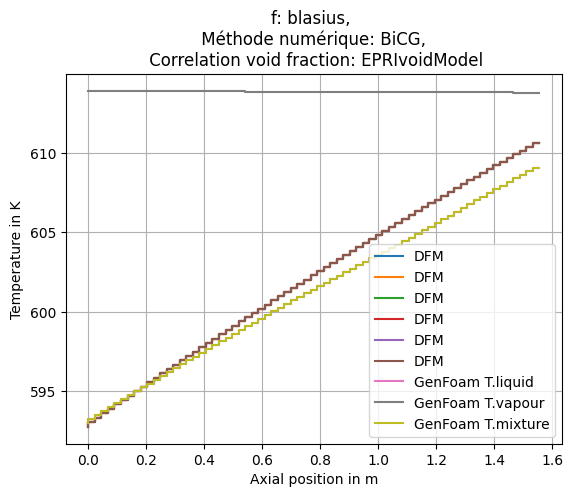

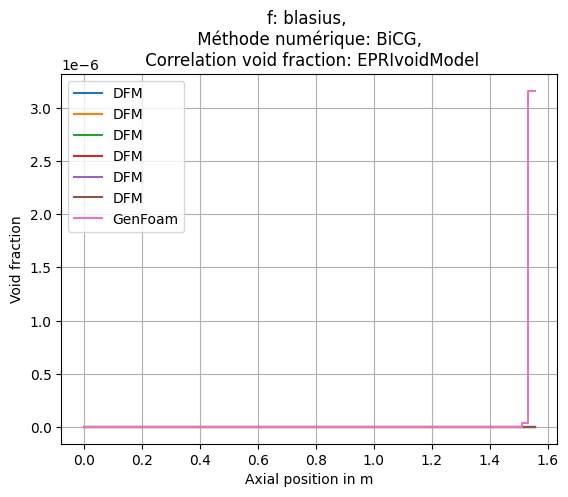

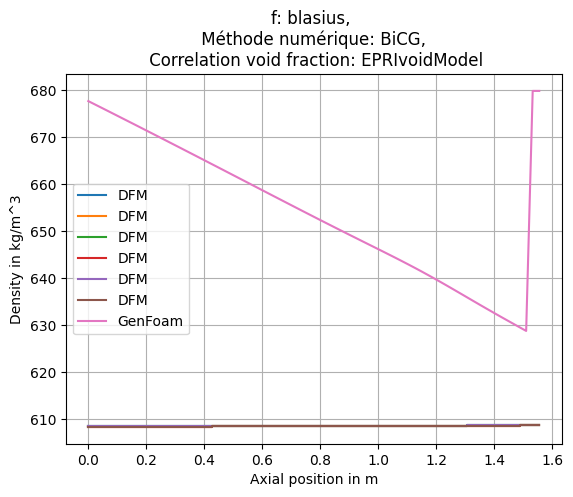

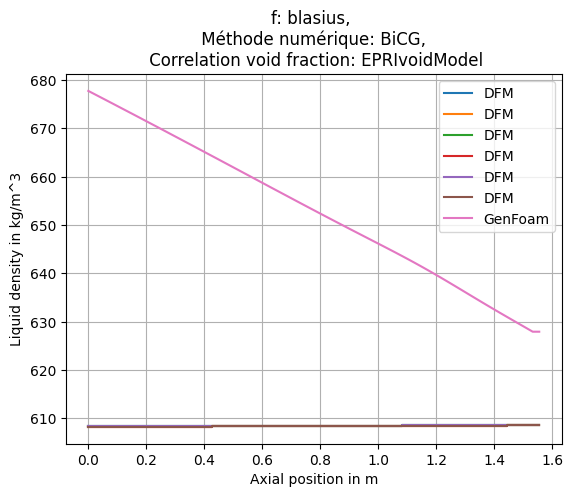

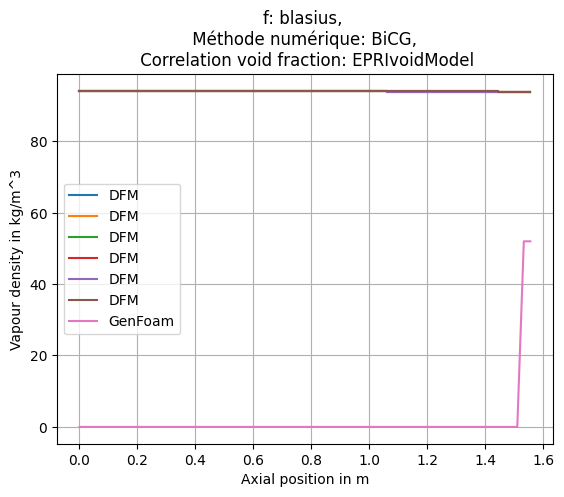

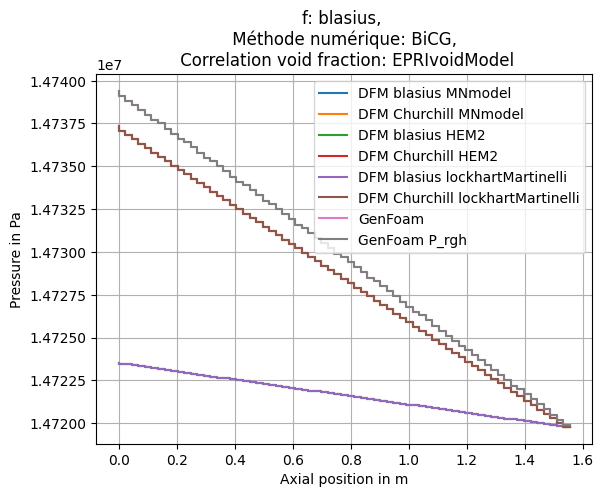

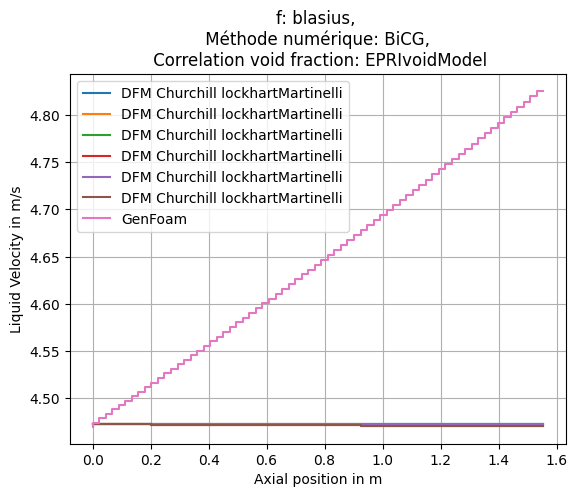

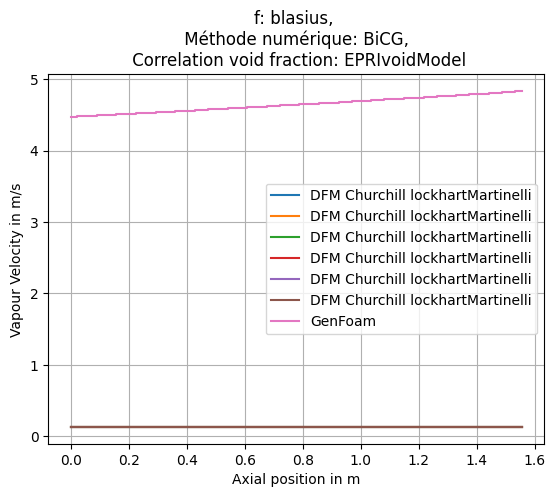

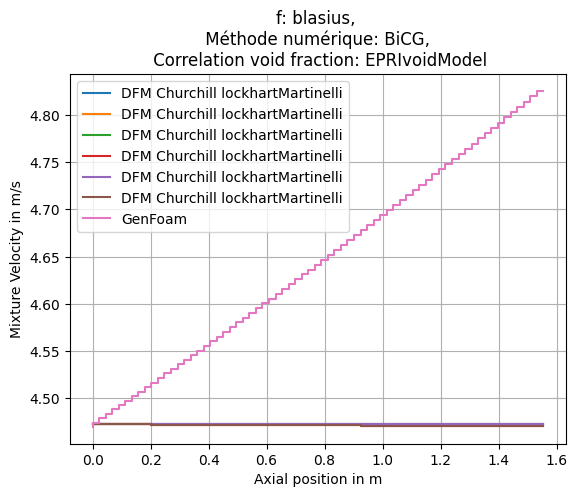

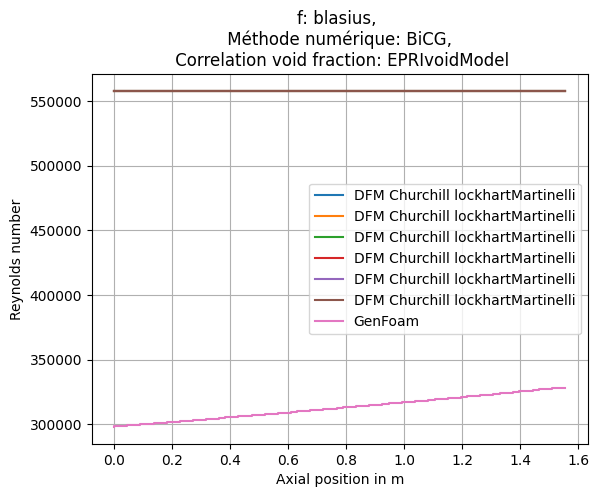

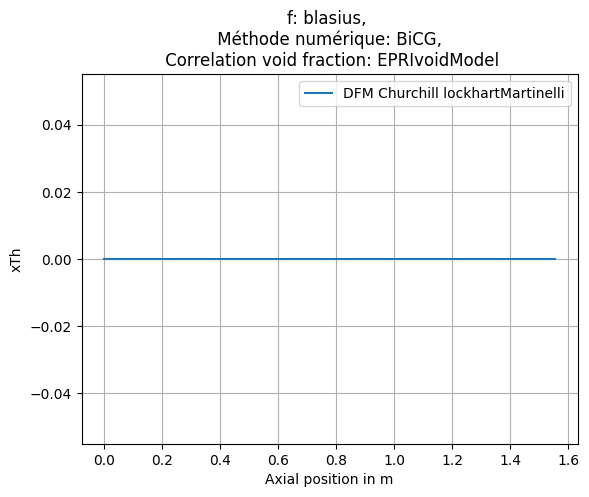

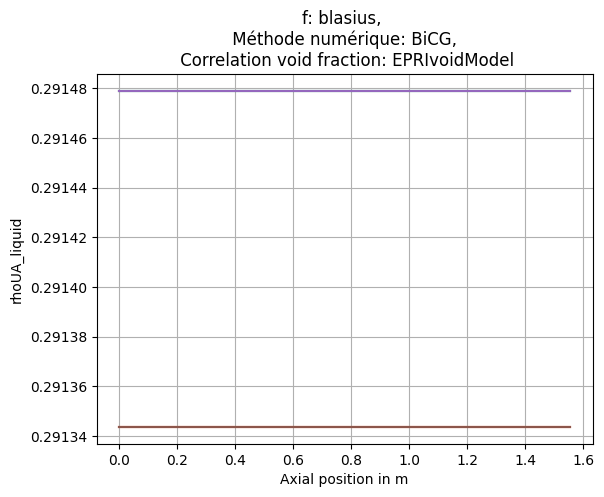

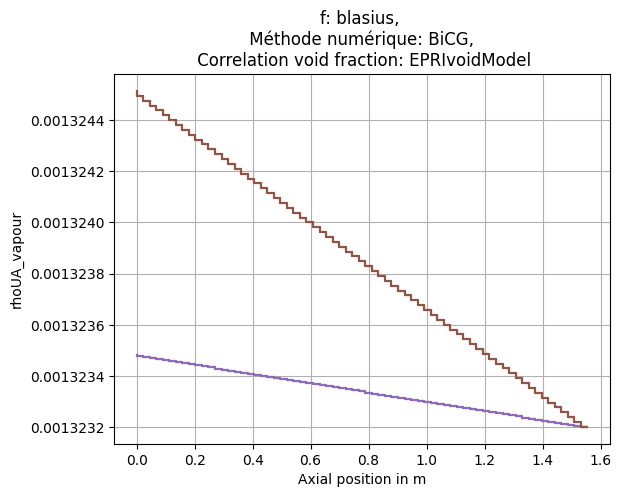

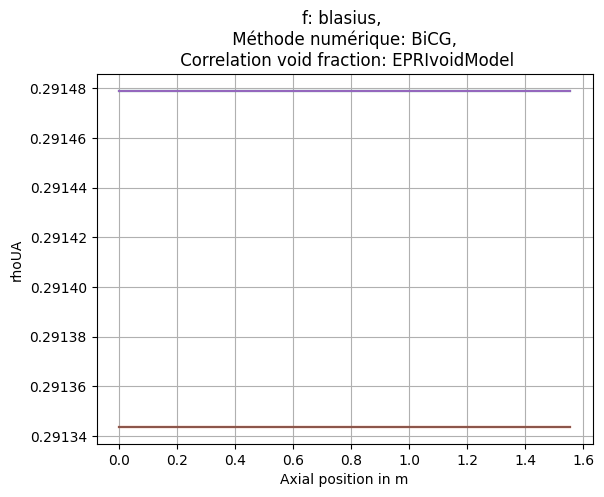

Mean relative error in temperature: 0.14160861541502692, max relative error in temperature 0.251293875582571 for blasius, MNmodel
Mean relative error in temperature: 0.1417894827757337, max relative error in temperature 0.25143601756638473 for Churchill, MNmodel
Mean relative error in temperature: 0.14160861541502692, max relative error in temperature 0.251293875582571 for blasius, HEM2
Mean relative error in temperature: 0.1417894827757337, max relative error in temperature 0.25143601756638473 for Churchill, HEM2
Mean relative error in temperature: 0.14160861541502692, max relative error in temperature 0.251293875582571 for blasius, lockhartMartinelli
Mean relative error in temperature: 0.1417894827757337, max relative error in temperature 0.25143601756638473 for Churchill, lockhartMartinelli
[0.14160861541502692, 0.1417894827757337, 0.14160861541502692, 0.1417894827757337, 0.14160861541502692, 0.1417894827757337]
Reading files in directory: C:\Users\cleme\OneDrive\Documents\Poly\BWR\

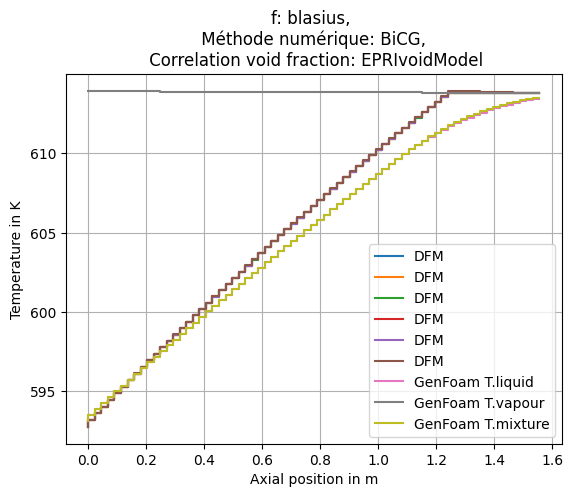

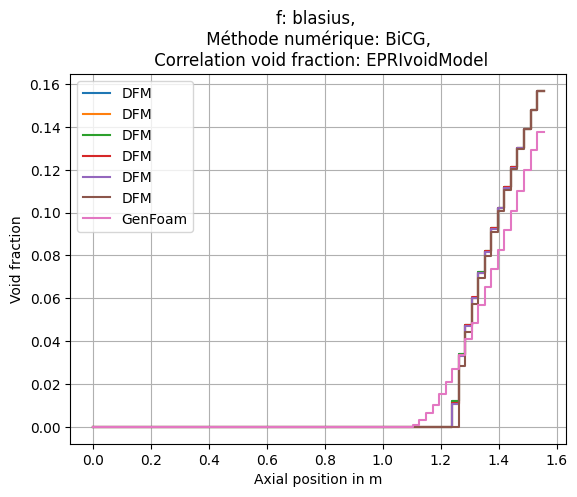

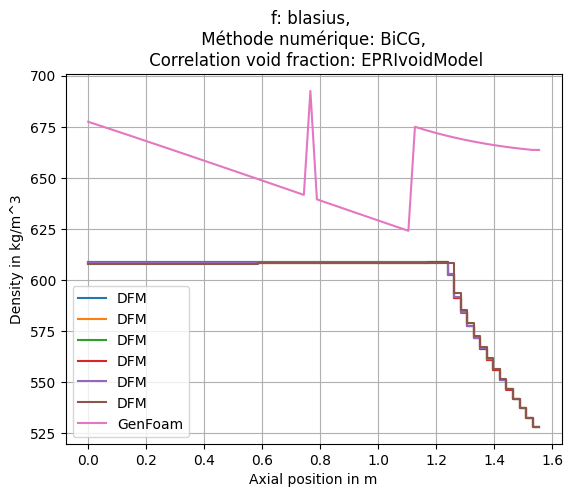

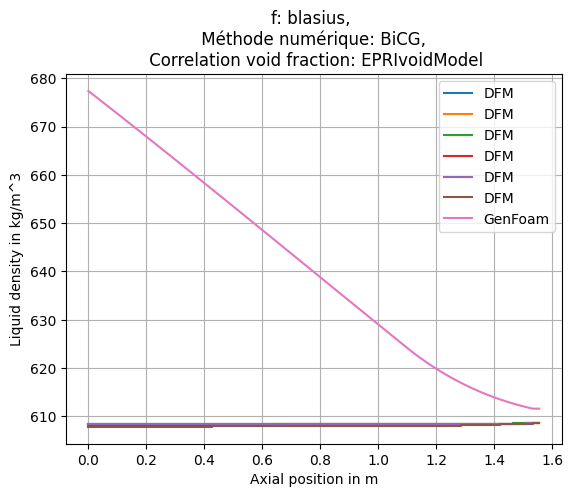

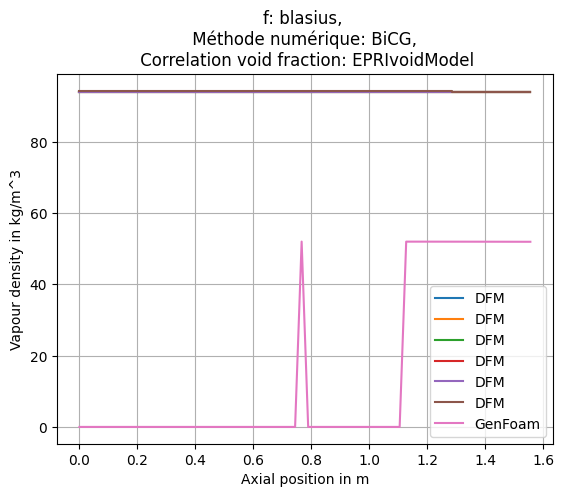

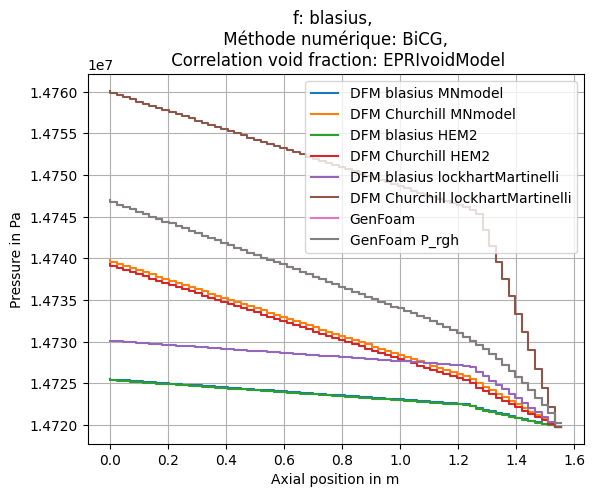

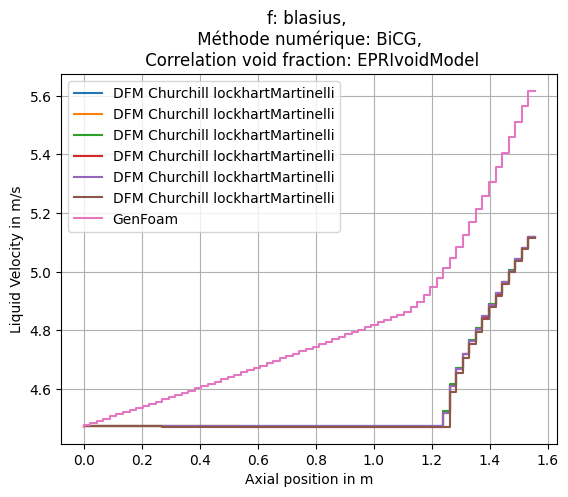

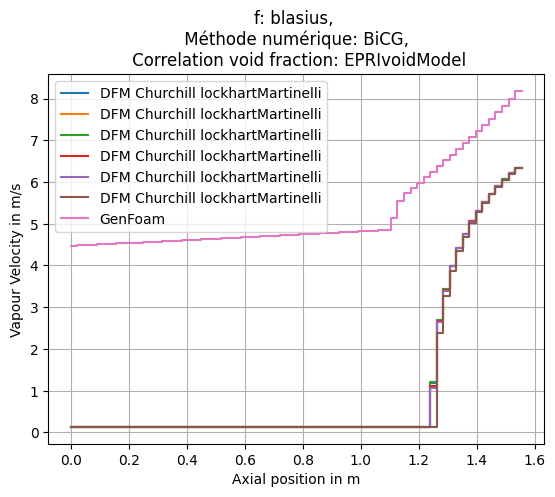

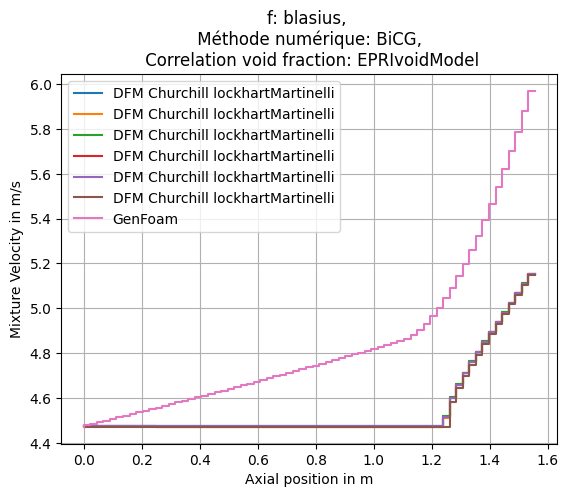

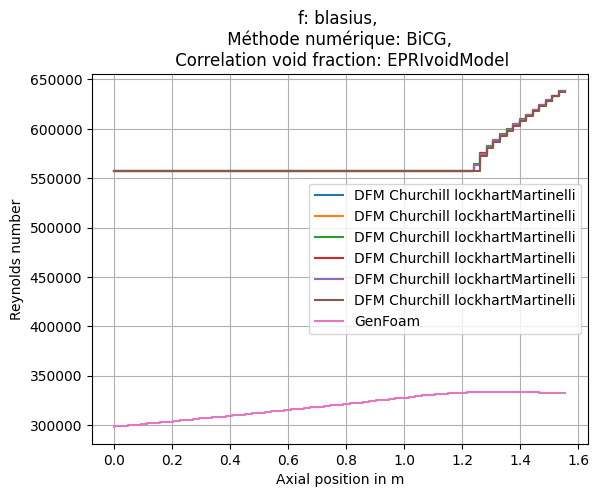

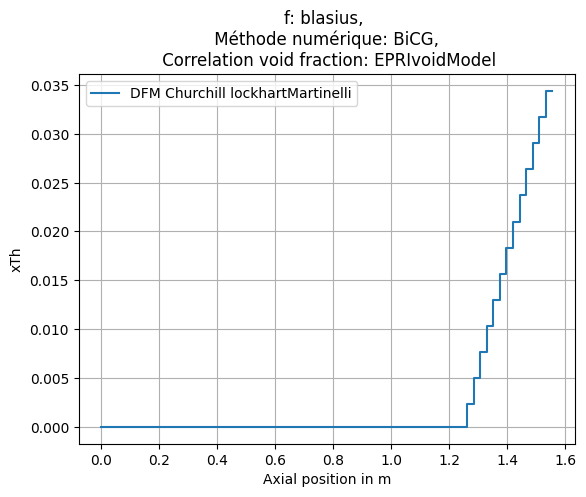

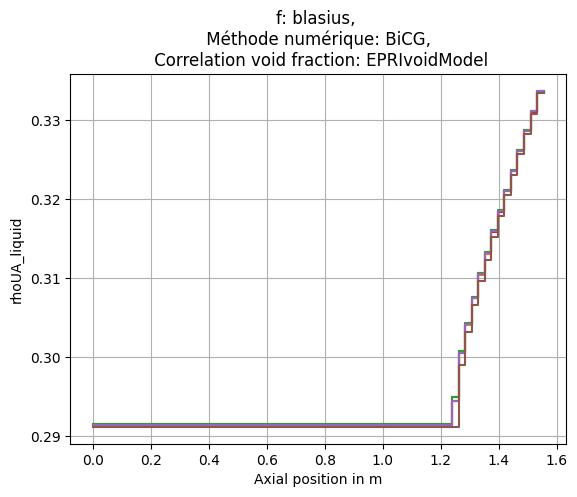

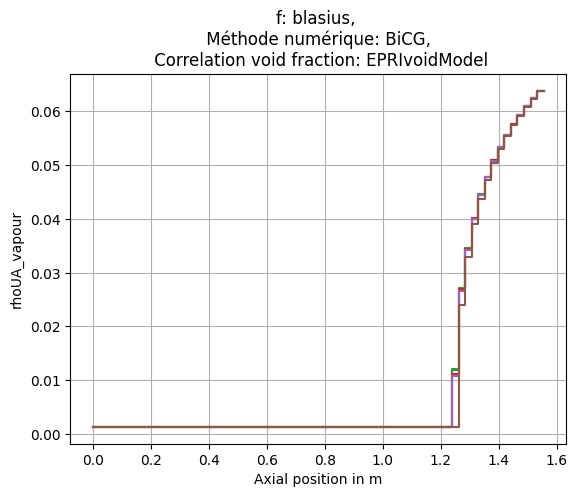

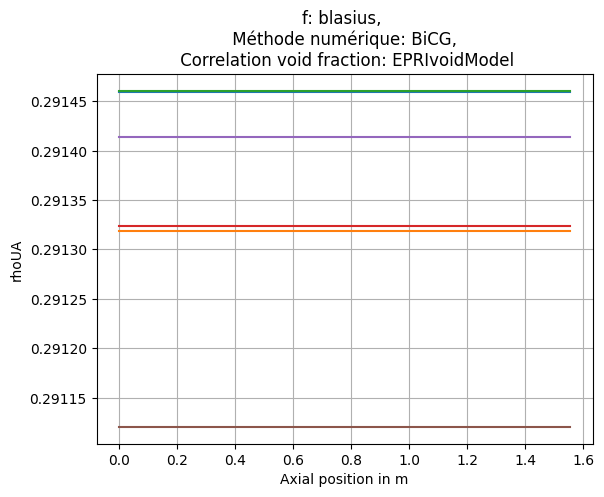

Mean relative error in temperature: 0.15360092690555857, max relative error in temperature 0.3360587331727944 for blasius, MNmodel
Mean relative error in temperature: 0.15431756438885635, max relative error in temperature 0.33885004561088383 for Churchill, MNmodel
Mean relative error in temperature: 0.1535819998711739, max relative error in temperature 0.335964818719998 for blasius, HEM2
Mean relative error in temperature: 0.15422822201121408, max relative error in temperature 0.338407617655062 for Churchill, HEM2
Mean relative error in temperature: 0.15433909551626573, max relative error in temperature 0.34016430420013516 for blasius, lockhartMartinelli
Mean relative error in temperature: 0.1575920964189055, max relative error in temperature 0.3511483434497377 for Churchill, lockhartMartinelli
[0.15360092690555857, 0.15431756438885635, 0.1535819998711739, 0.15422822201121408, 0.15433909551626573, 0.1575920964189055]
Reading files in directory: C:\Users\cleme\OneDrive\Documents\Poly\BW

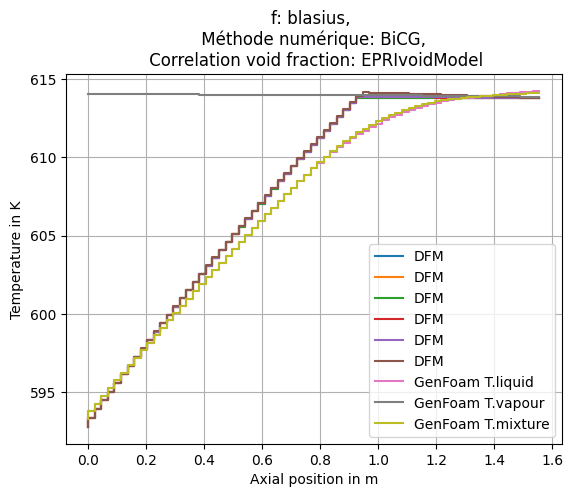

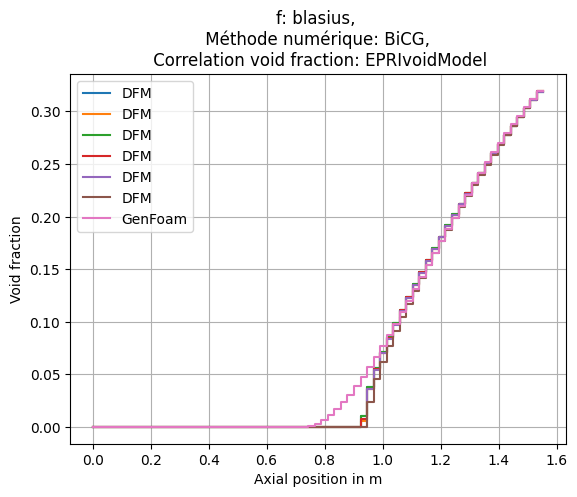

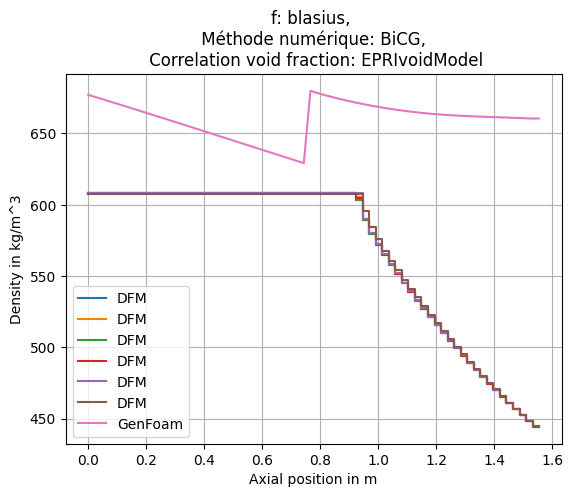

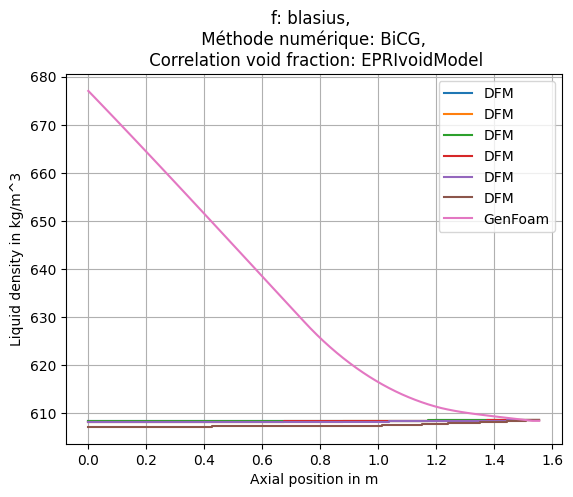

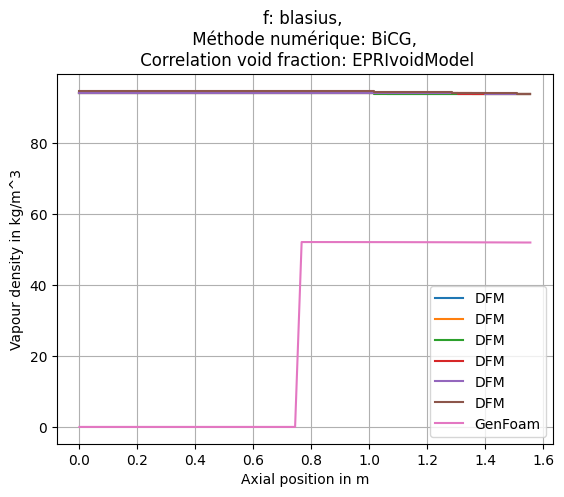

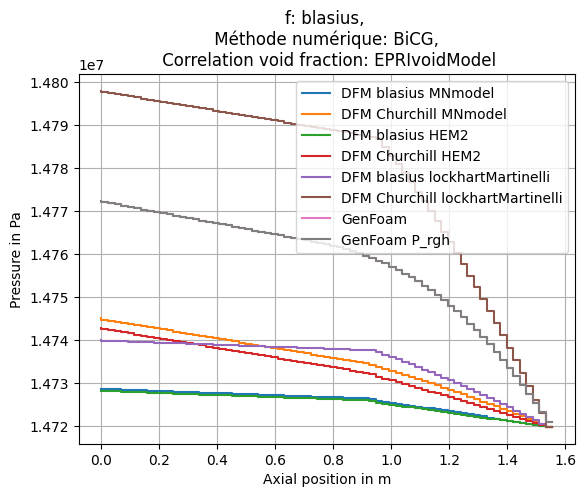

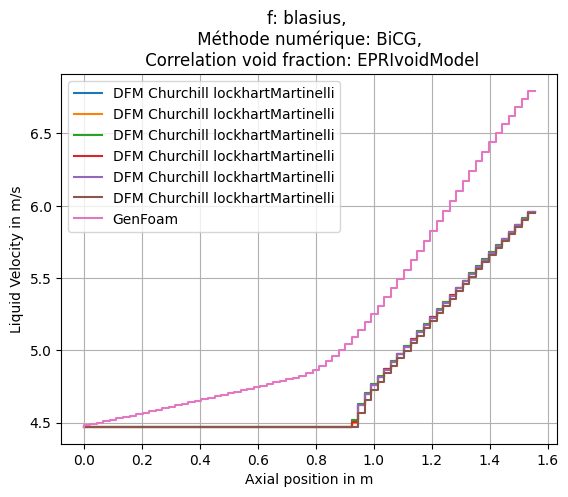

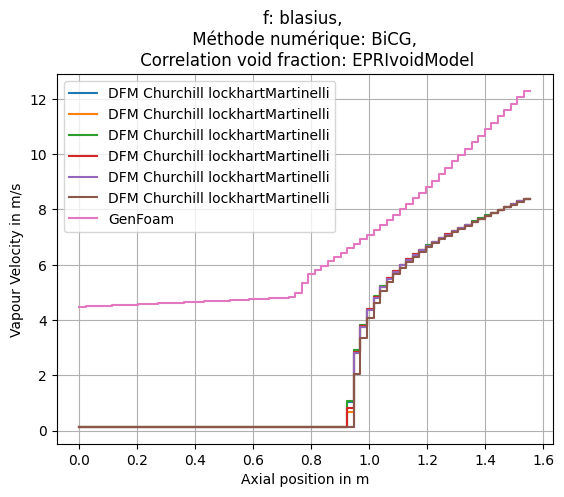

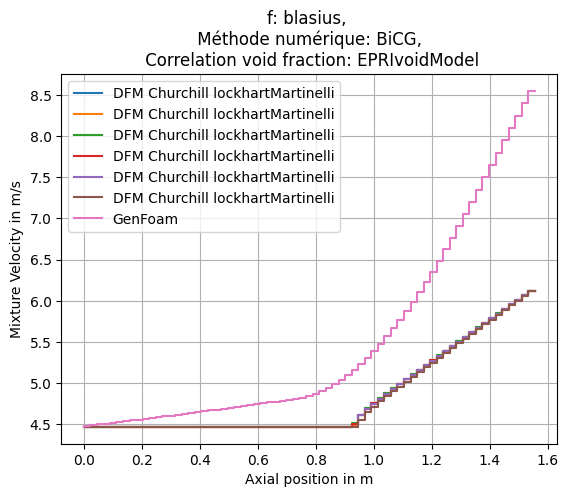

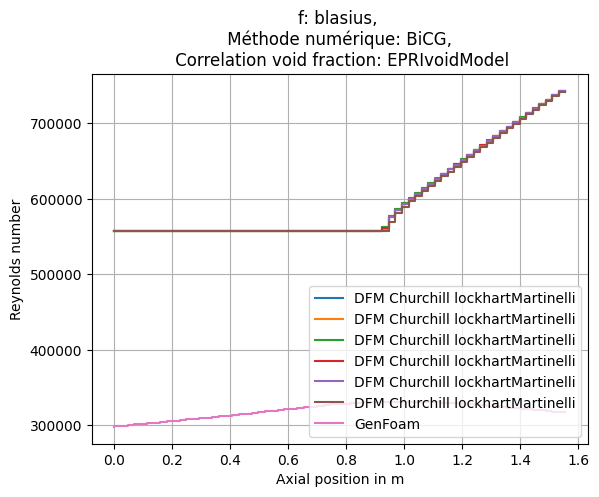

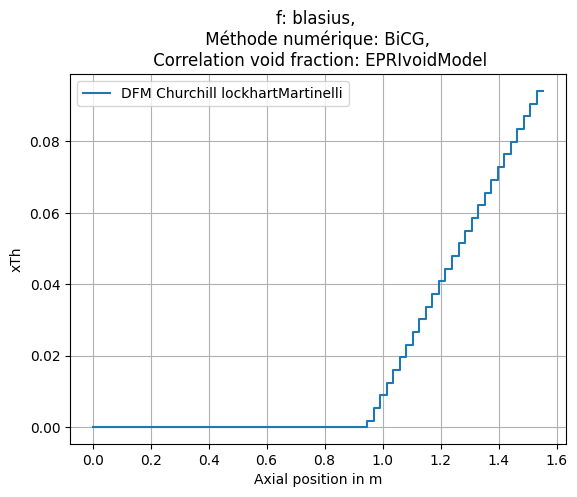

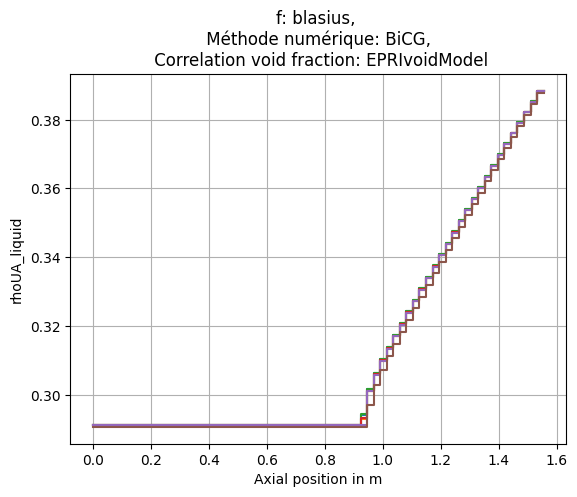

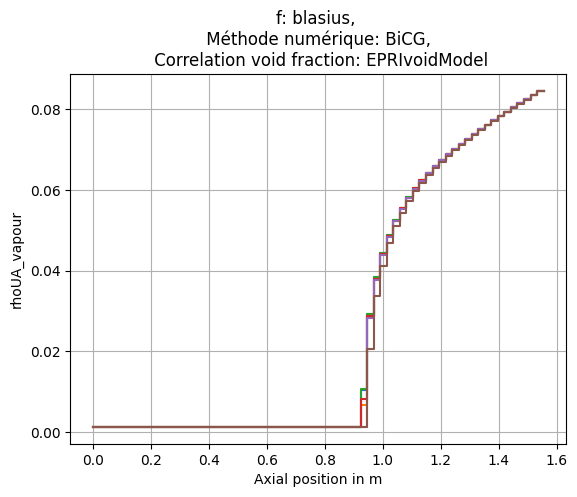

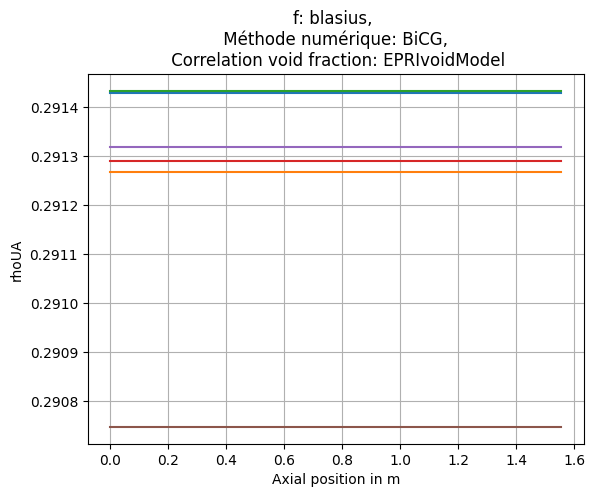

Mean relative error in temperature: 0.12282526791087275, max relative error in temperature 0.3655904268390824 for blasius, MNmodel
Mean relative error in temperature: 0.12437617229238995, max relative error in temperature 0.3726990101481322 for Churchill, MNmodel
Mean relative error in temperature: 0.12274350998720779, max relative error in temperature 0.36517826003985204 for blasius, HEM2
Mean relative error in temperature: 0.12395249329095558, max relative error in temperature 0.3707287725894276 for Churchill, HEM2
Mean relative error in temperature: 0.12488280416823616, max relative error in temperature 0.3754617713217979 for blasius, lockhartMartinelli
Mean relative error in temperature: 0.13438358540276513, max relative error in temperature 0.3843091544831677 for Churchill, lockhartMartinelli
[0.12282526791087275, 0.12437617229238995, 0.12274350998720779, 0.12395249329095558, 0.12488280416823616, 0.13438358540276513]
Reading files in directory: C:\Users\cleme\OneDrive\Documents\Po

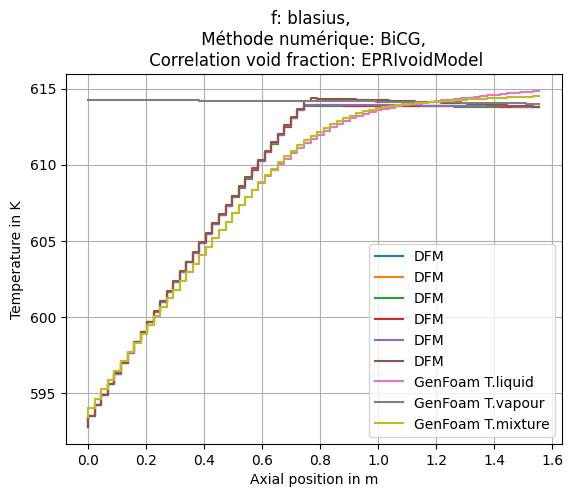

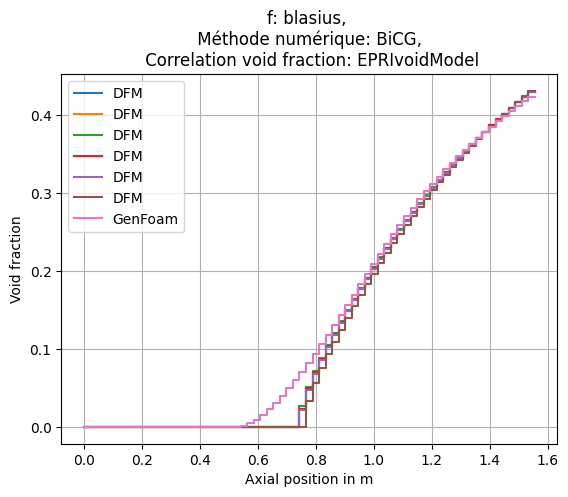

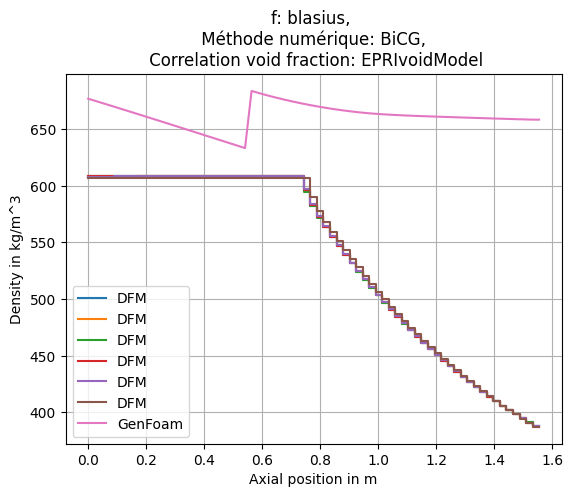

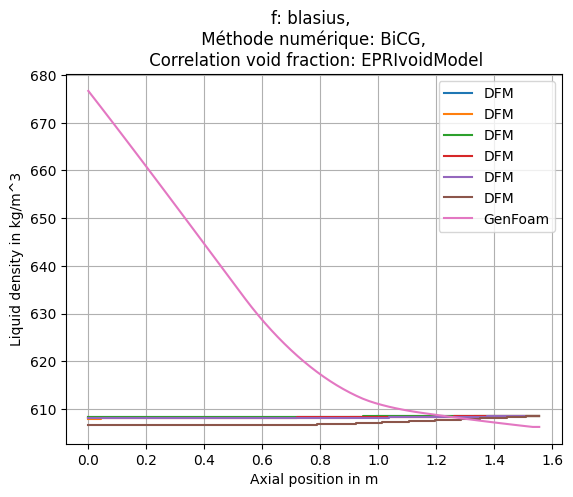

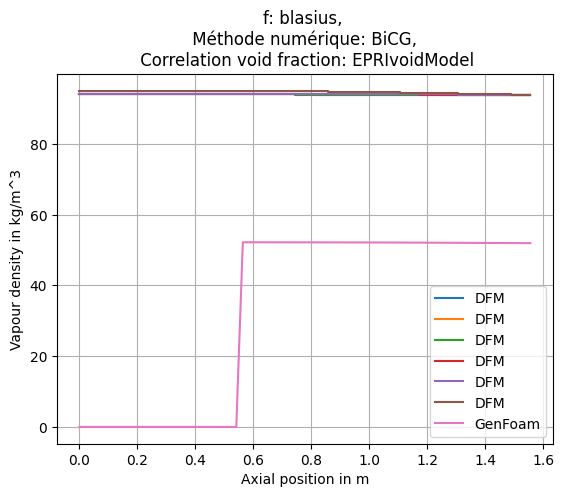

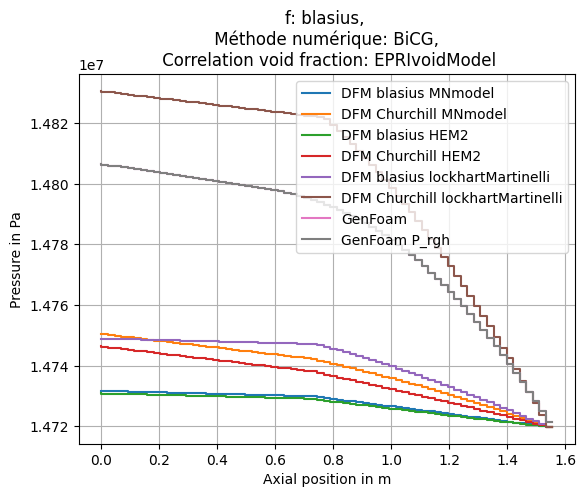

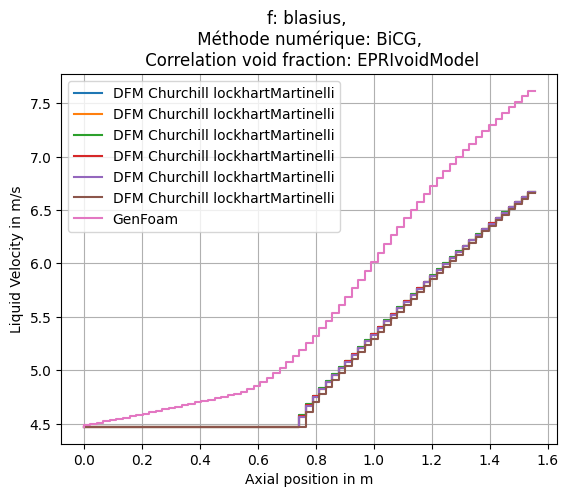

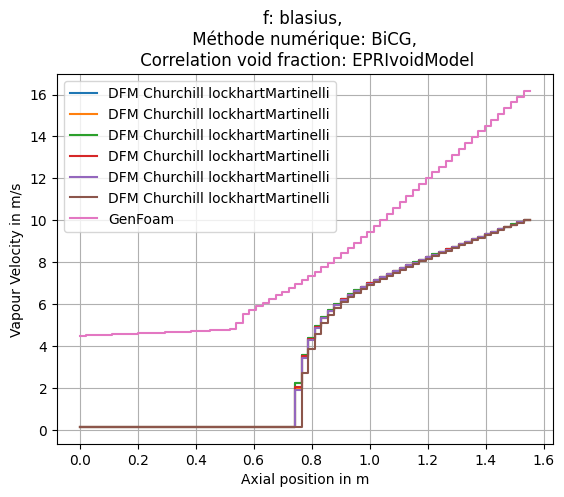

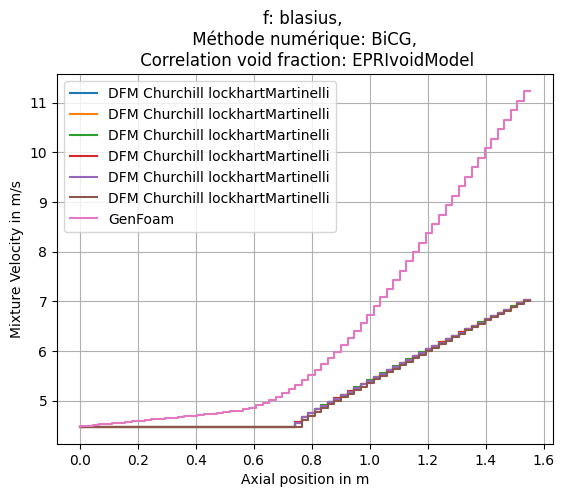

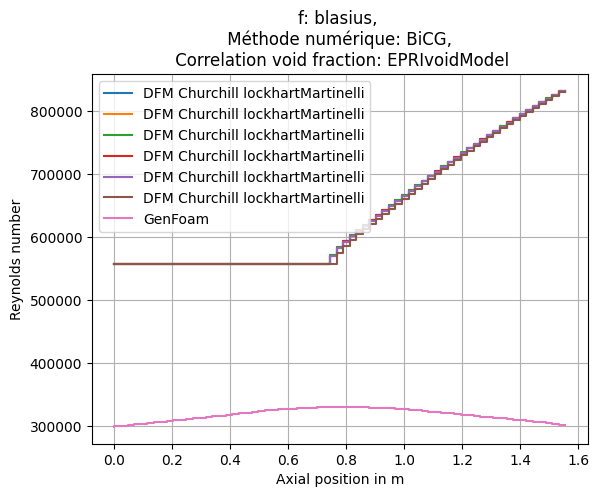

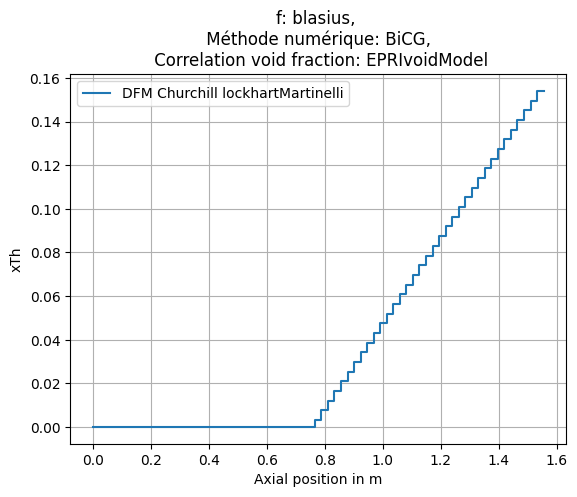

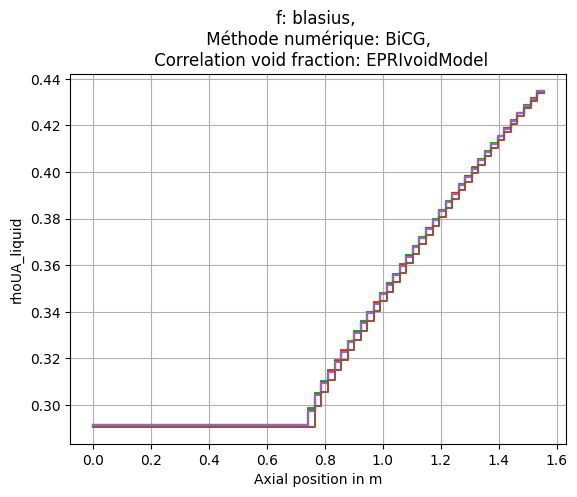

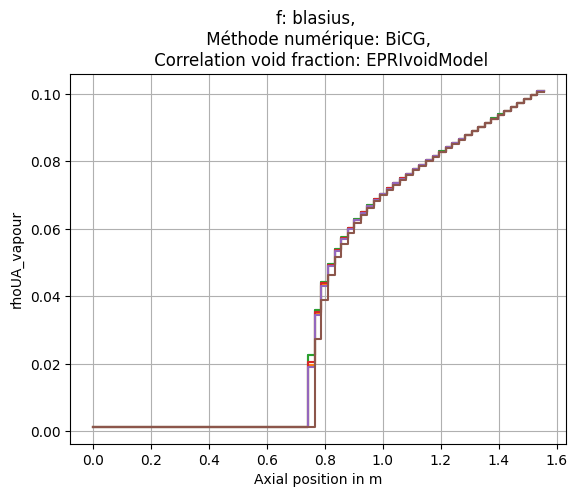

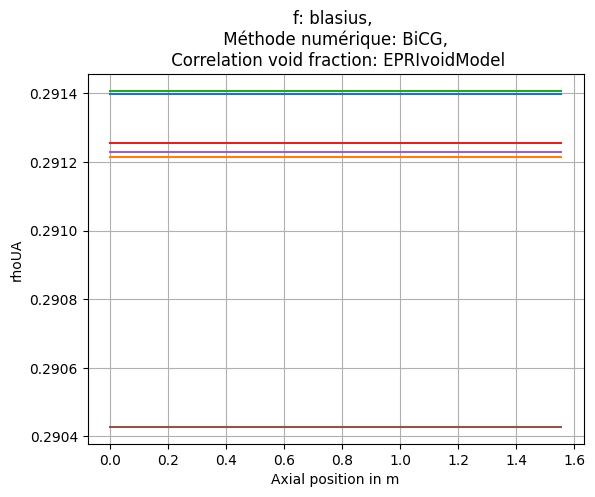

Mean relative error in temperature: 0.11814958906688124, max relative error in temperature 0.37745376147397375 for blasius, MNmodel
Mean relative error in temperature: 0.11928262089773141, max relative error in temperature 0.38174274394180846 for Churchill, MNmodel
Mean relative error in temperature: 0.11809619725936782, max relative error in temperature 0.3773086243448855 for blasius, HEM2
Mean relative error in temperature: 0.11894435269118164, max relative error in temperature 0.379009027202169 for Churchill, HEM2
Mean relative error in temperature: 0.11969074061296206, max relative error in temperature 0.38633045423249174 for blasius, lockhartMartinelli
Mean relative error in temperature: 0.12984772863160643, max relative error in temperature 0.42746126523413935 for Churchill, lockhartMartinelli
[0.11814958906688124, 0.11928262089773141, 0.11809619725936782, 0.11894435269118164, 0.11969074061296206, 0.12984772863160643]
Reading files in directory: C:\Users\cleme\OneDrive\Documents\

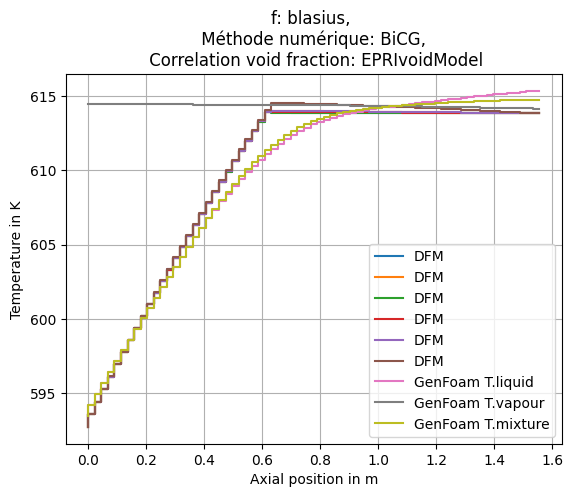

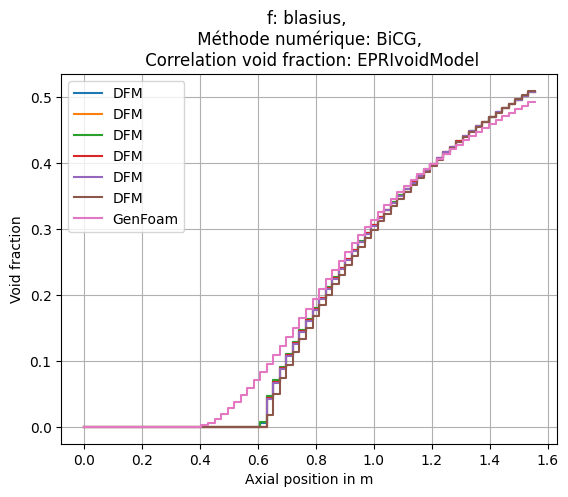

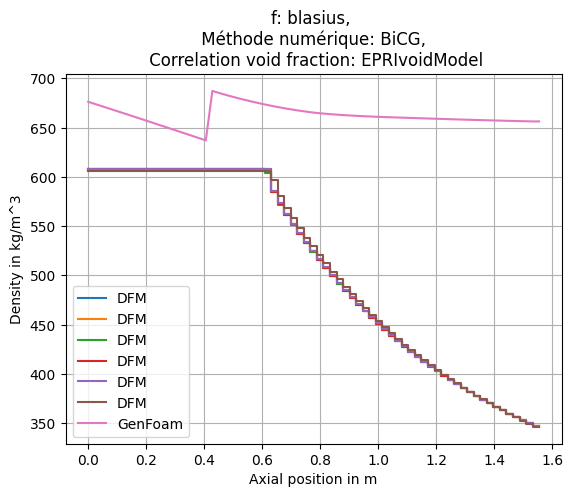

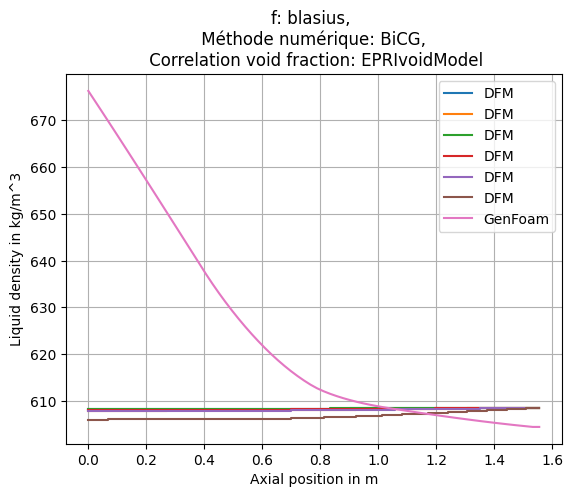

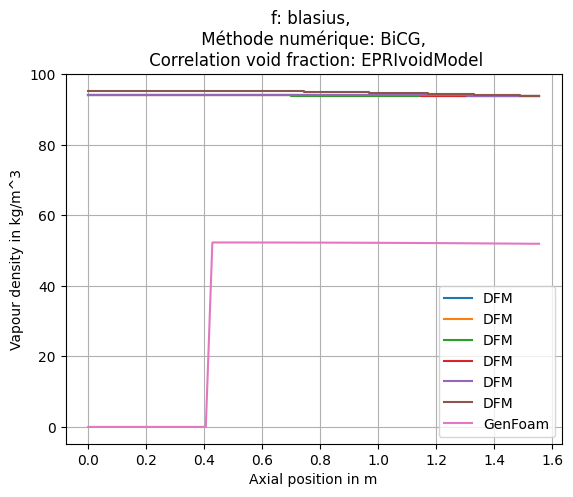

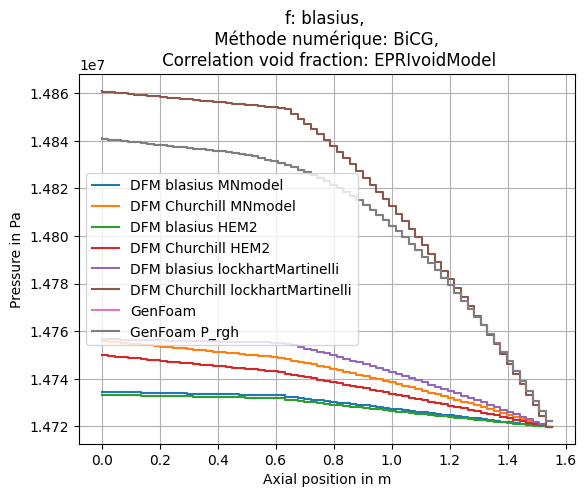

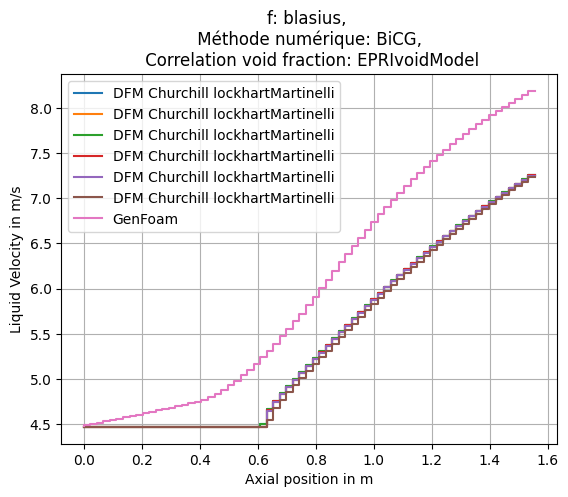

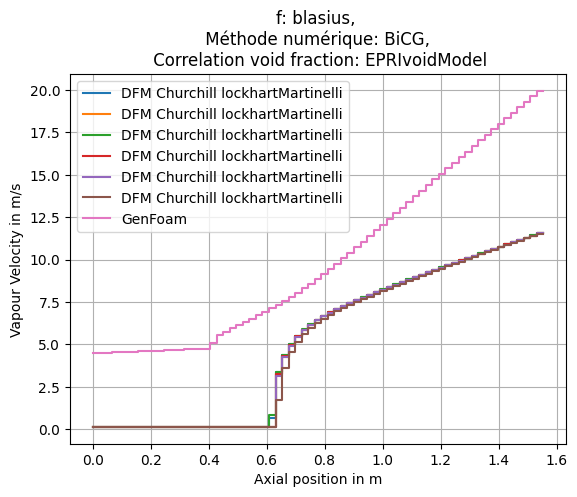

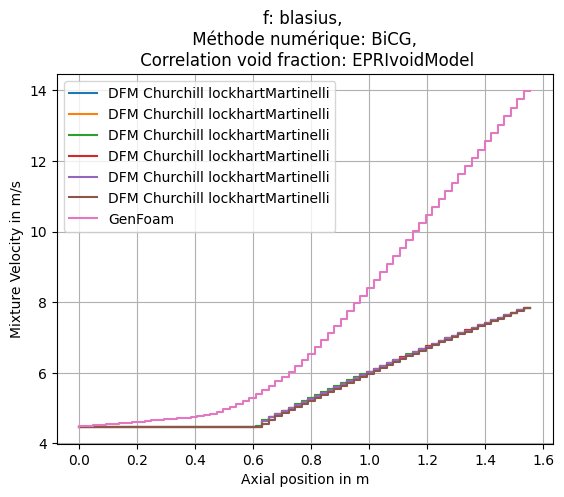

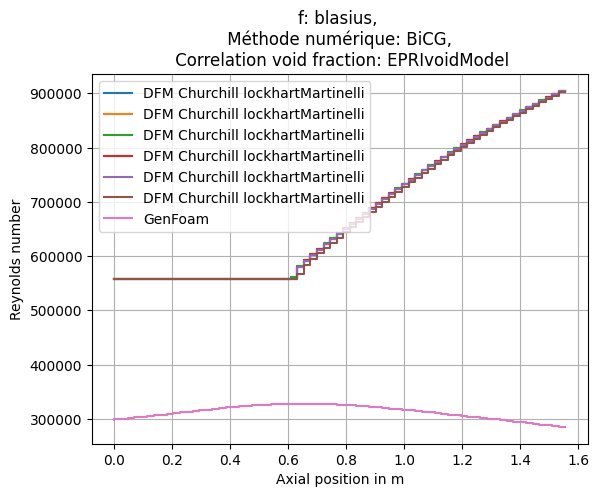

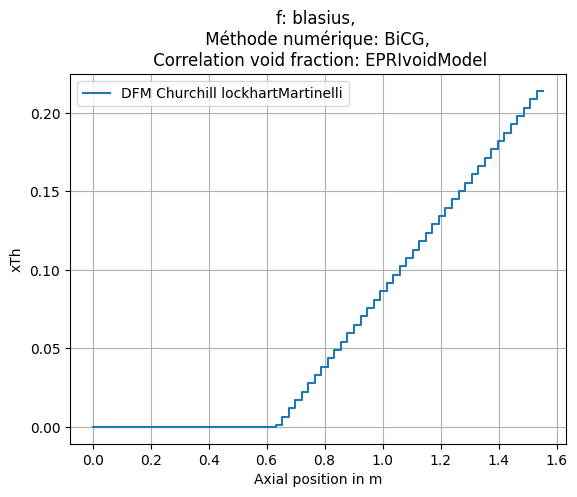

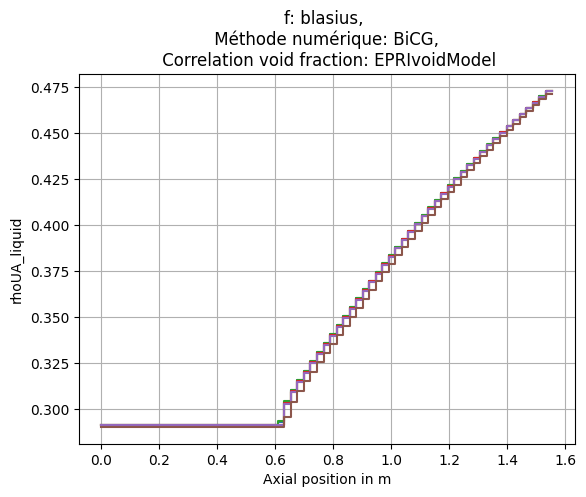

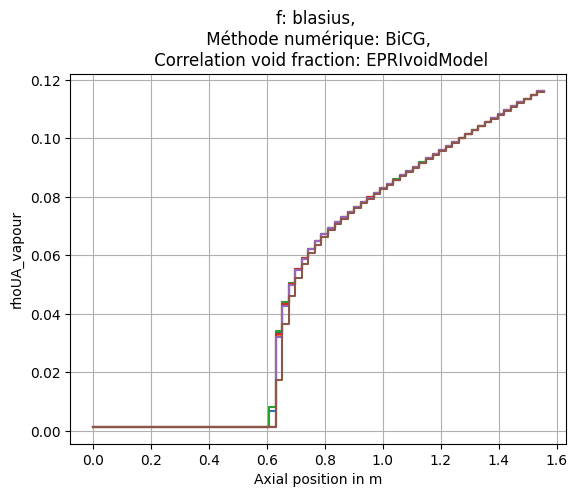

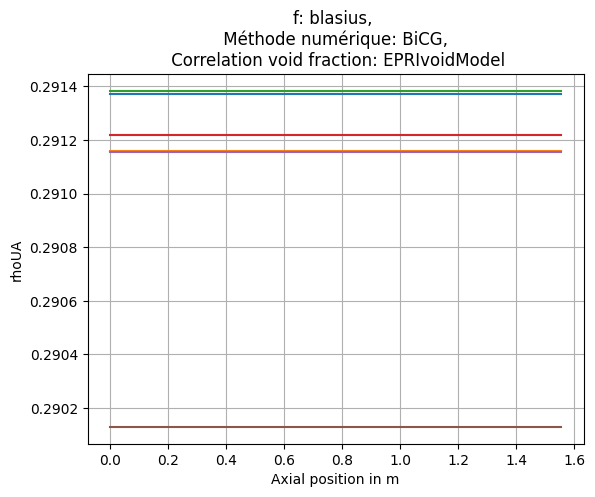

Mean relative error in temperature: 0.12595716466478507, max relative error in temperature 0.4151279960171373 for blasius, MNmodel
Mean relative error in temperature: 0.12609180149156268, max relative error in temperature 0.42112750230364004 for Churchill, MNmodel
Mean relative error in temperature: 0.1259707828699643, max relative error in temperature 0.4140229526183621 for blasius, HEM2
Mean relative error in temperature: 0.12609710849515837, max relative error in temperature 0.4200933602179683 for Churchill, HEM2
Mean relative error in temperature: 0.12616684178634463, max relative error in temperature 0.42205601043450736 for blasius, lockhartMartinelli
Mean relative error in temperature: 0.13337328741083285, max relative error in temperature 0.4616120962722552 for Churchill, lockhartMartinelli
[0.12595716466478507, 0.12609180149156268, 0.1259707828699643, 0.12609710849515837, 0.12616684178634463, 0.13337328741083285]
Reading files in directory: C:\Users\cleme\OneDrive\Documents\Pol

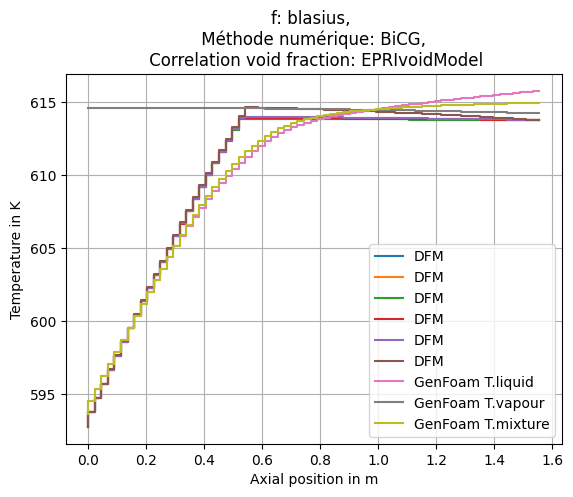

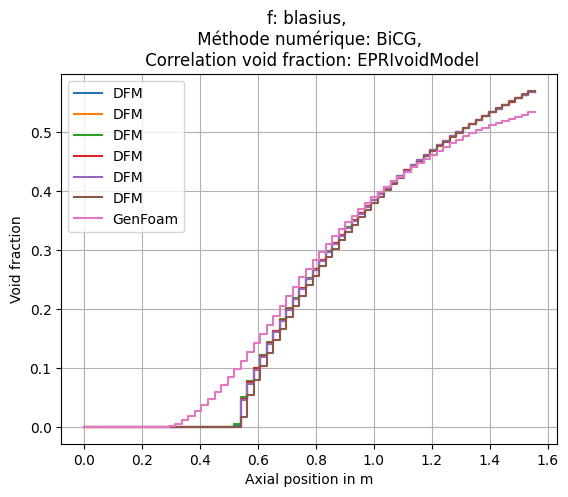

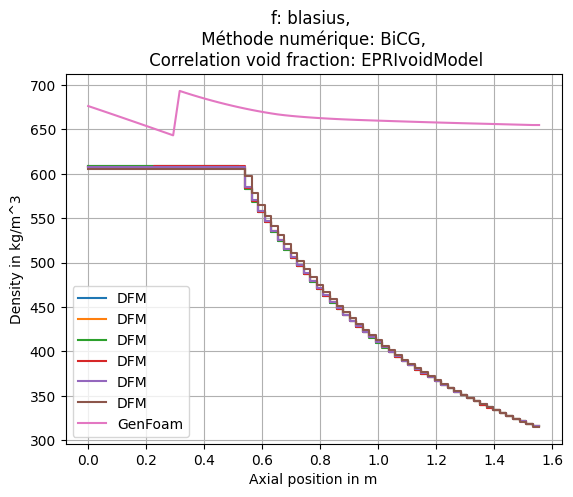

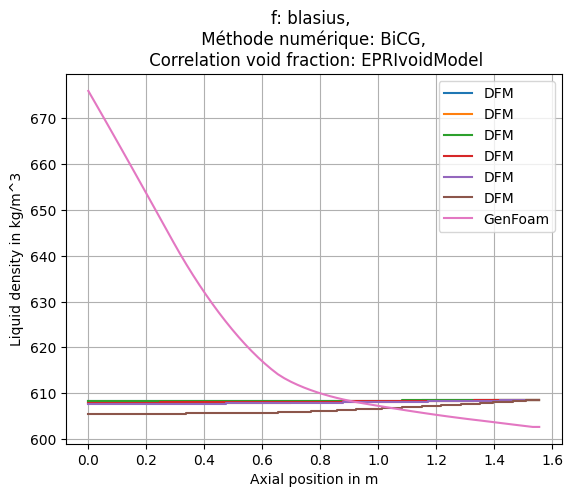

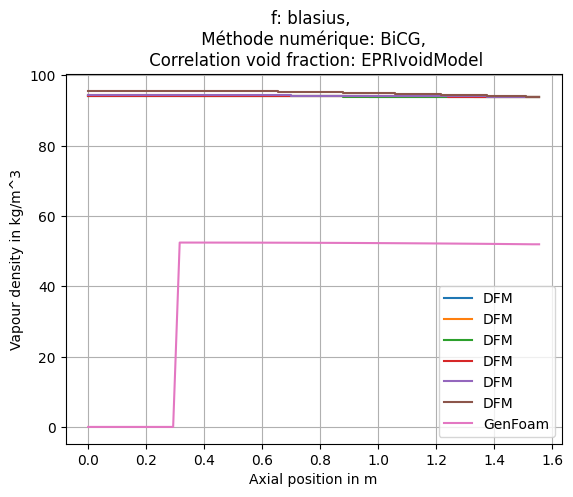

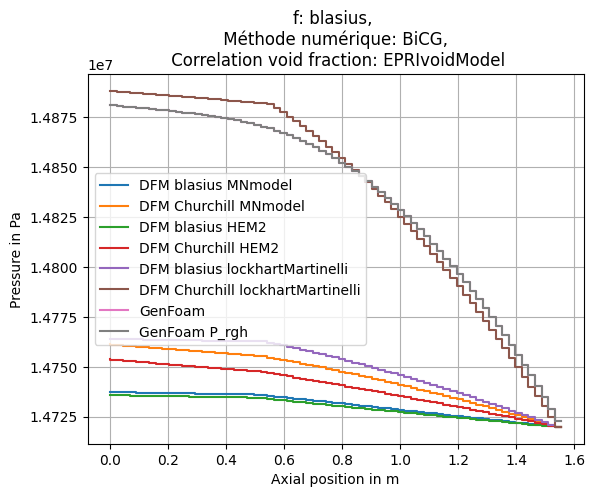

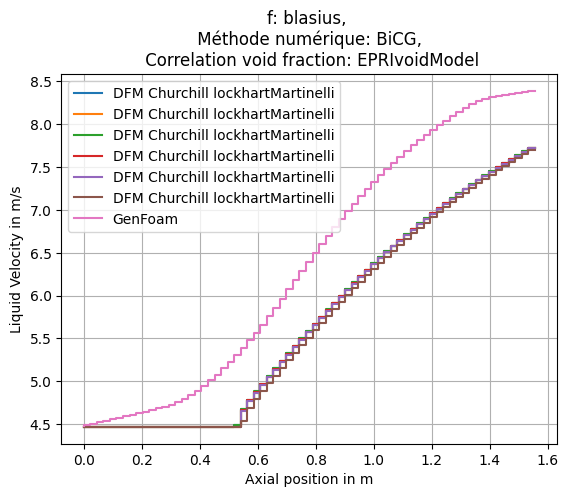

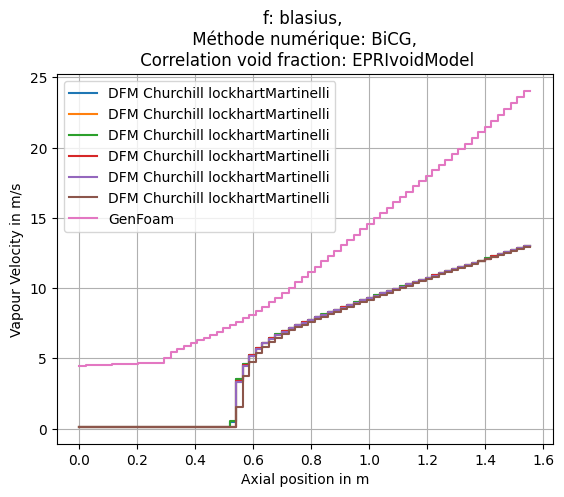

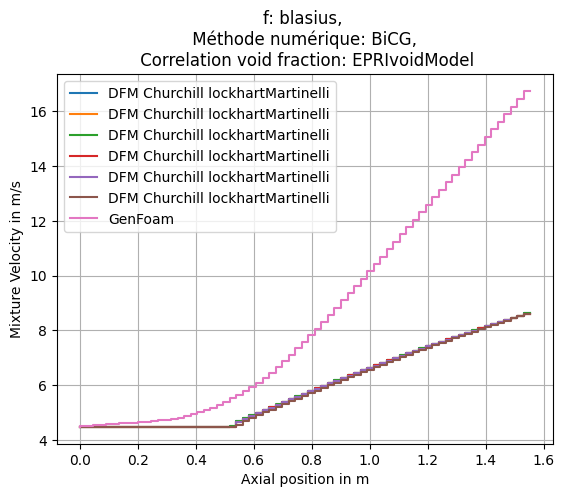

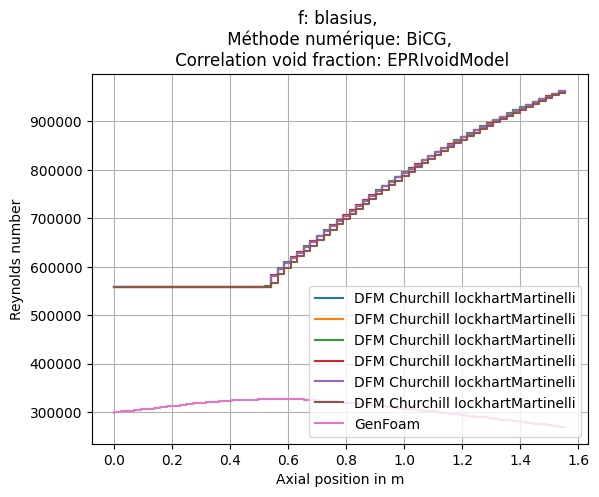

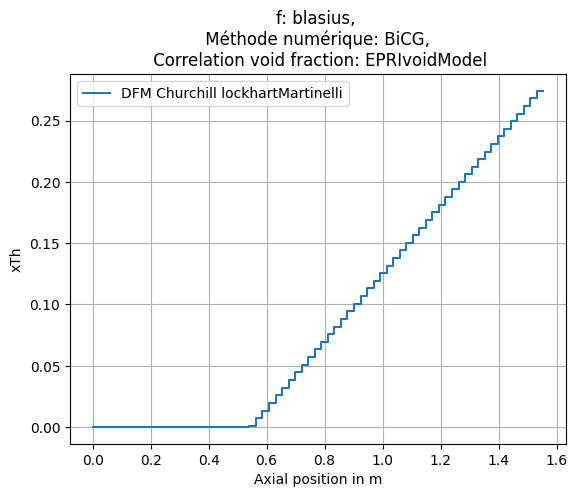

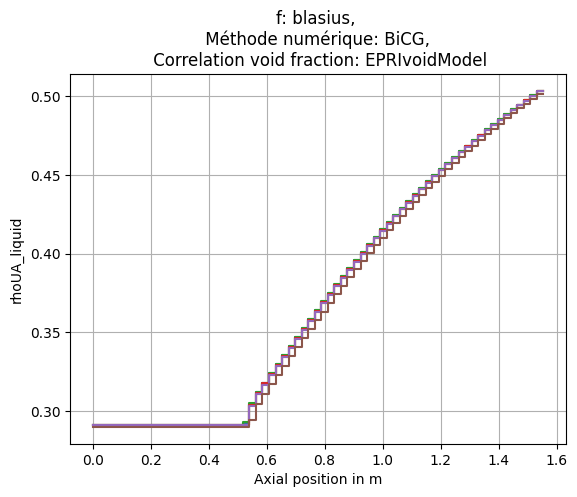

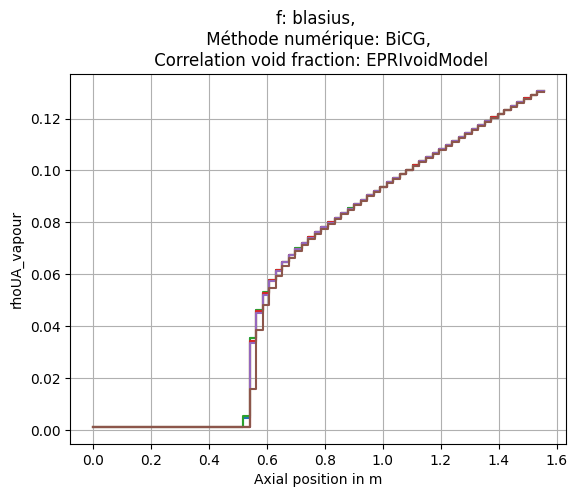

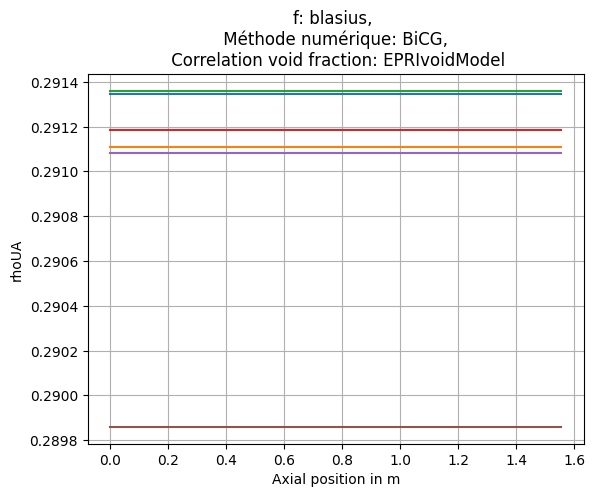

Mean relative error in temperature: 0.1406753944257383, max relative error in temperature 0.43451268930579784 for blasius, MNmodel
Mean relative error in temperature: 0.13953348361106357, max relative error in temperature 0.43896712259904797 for Churchill, MNmodel
Mean relative error in temperature: 0.14078445731993475, max relative error in temperature 0.4331023915819829 for blasius, HEM2
Mean relative error in temperature: 0.1401593584163741, max relative error in temperature 0.4376267052139056 for Churchill, HEM2
Mean relative error in temperature: 0.13924485162155, max relative error in temperature 0.44011436847827273 for blasius, lockhartMartinelli
Mean relative error in temperature: 0.1413234645489723, max relative error in temperature 0.4939309753526388 for Churchill, lockhartMartinelli
[0.1406753944257383, 0.13953348361106357, 0.14078445731993475, 0.1401593584163741, 0.13924485162155, 0.1413234645489723]
Reading files in directory: C:\Users\cleme\OneDrive\Documents\Poly\BWR\dri

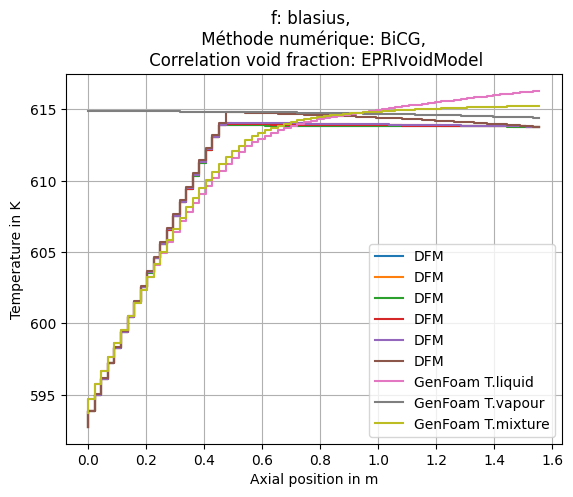

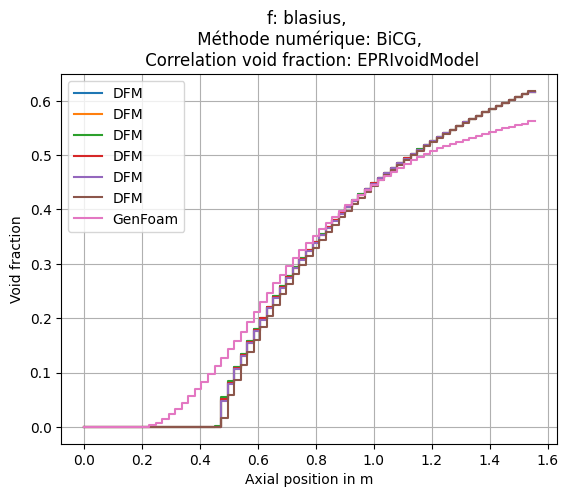

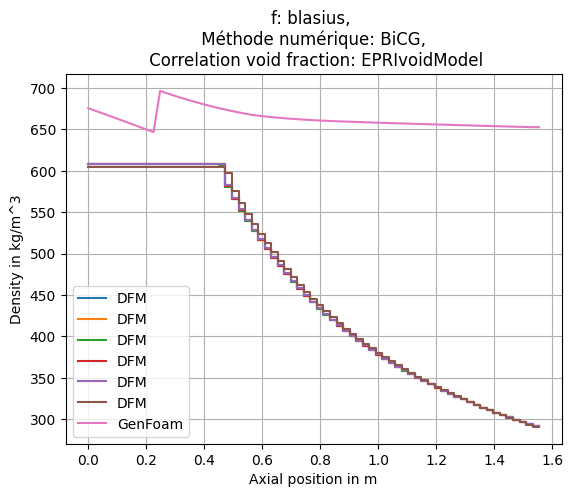

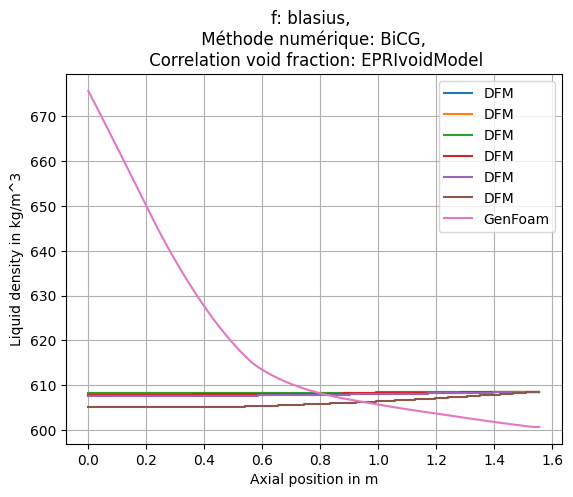

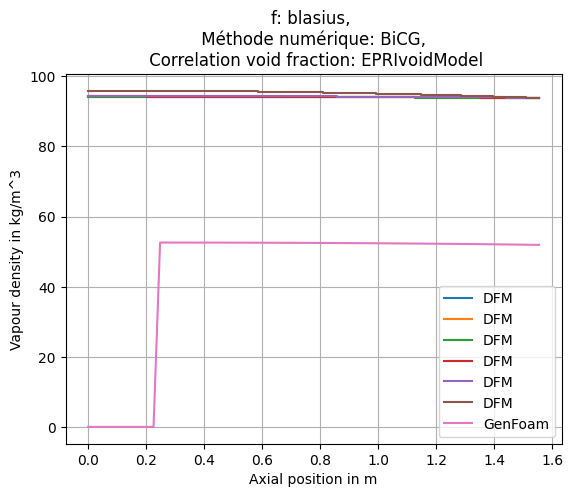

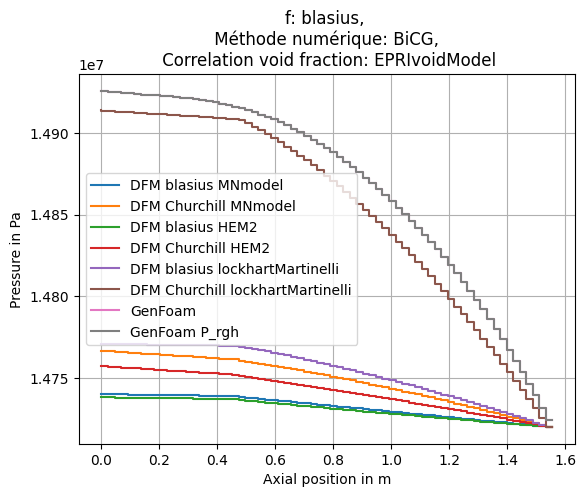

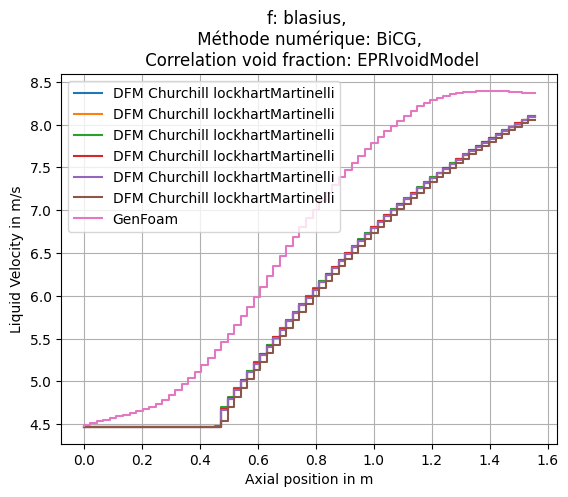

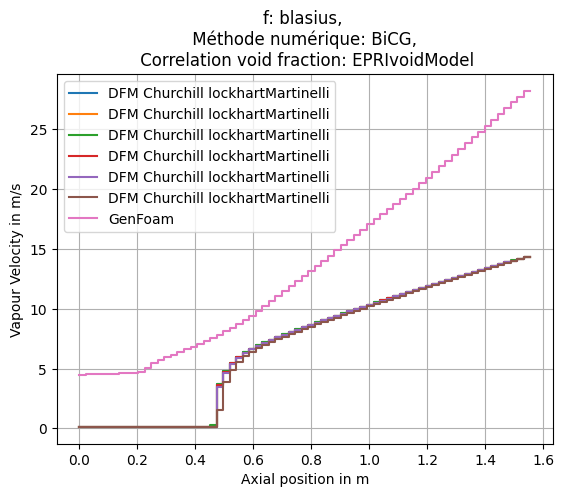

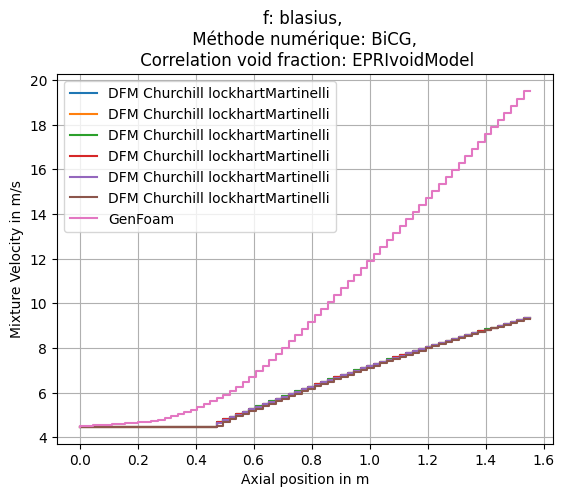

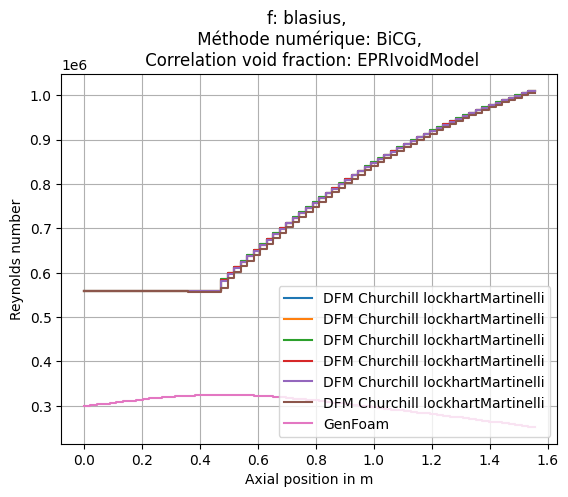

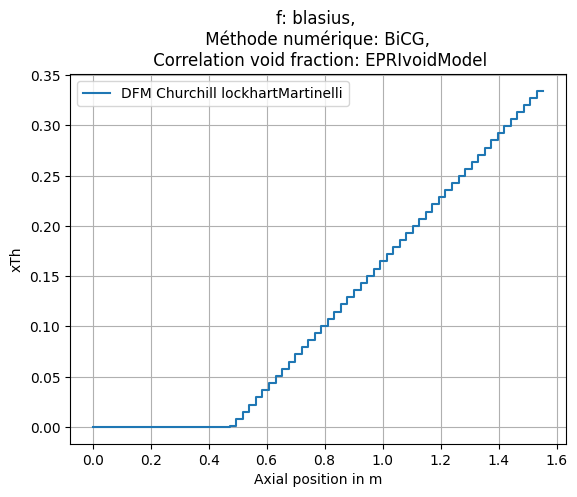

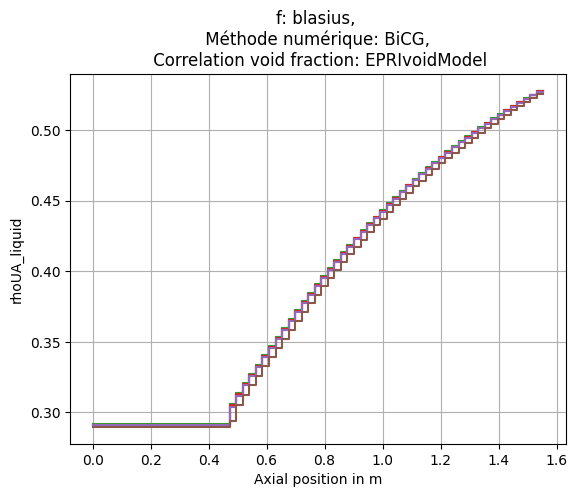

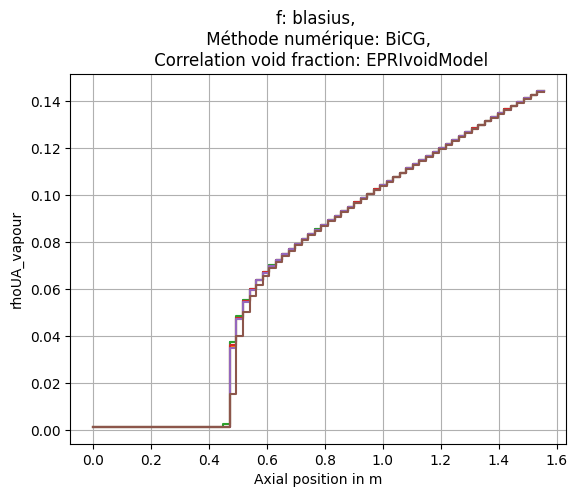

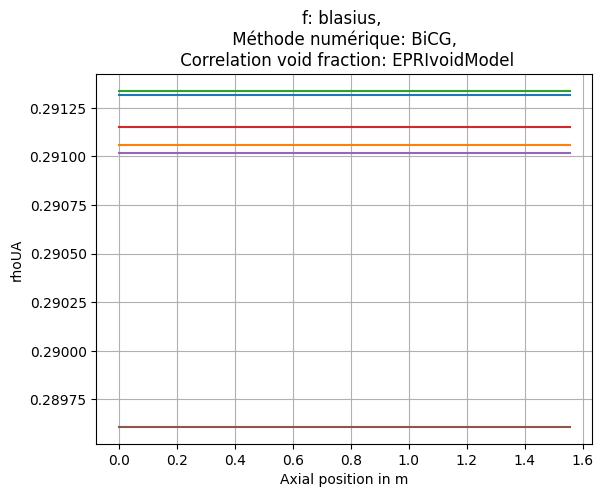

Mean relative error in temperature: 0.1620140384139305, max relative error in temperature 0.44777035673595417 for blasius, MNmodel
Mean relative error in temperature: 0.1595209158218133, max relative error in temperature 0.45177737154836384 for Churchill, MNmodel
Mean relative error in temperature: 0.1622740823793145, max relative error in temperature 0.44708257996444556 for blasius, HEM2
Mean relative error in temperature: 0.1607607641600483, max relative error in temperature 0.4501489313586489 for Churchill, HEM2
Mean relative error in temperature: 0.1586868124631199, max relative error in temperature 0.453115306545287 for blasius, lockhartMartinelli
Mean relative error in temperature: 0.15379034977821276, max relative error in temperature 0.5194069413393807 for Churchill, lockhartMartinelli
[0.1620140384139305, 0.1595209158218133, 0.1622740823793145, 0.1607607641600483, 0.1586868124631199, 0.15379034977821276]
Reading files in directory: C:\Users\cleme\OneDrive\Documents\Poly\BWR\dr

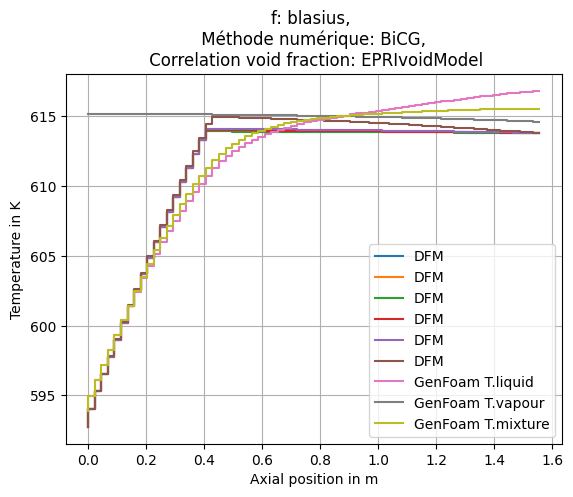

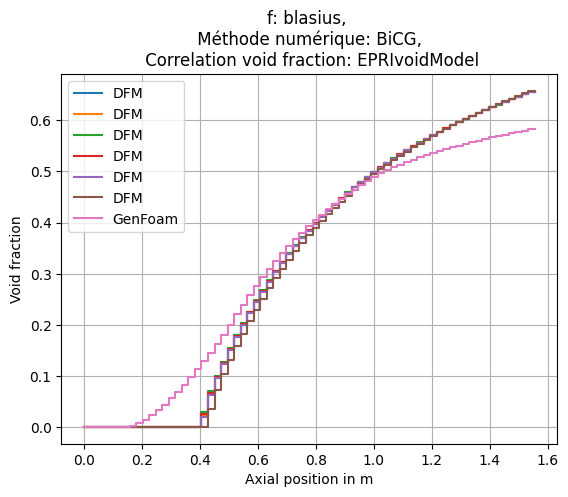

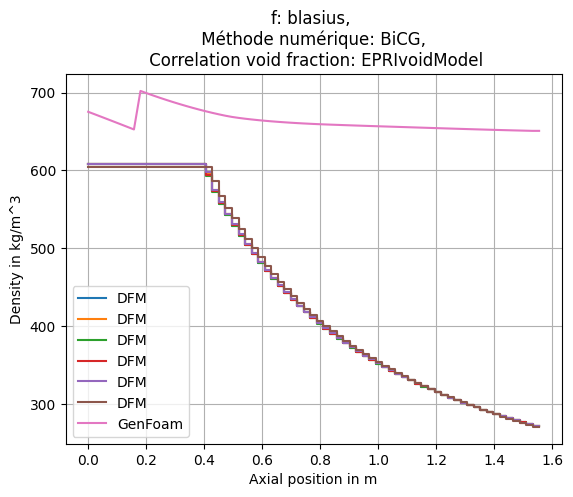

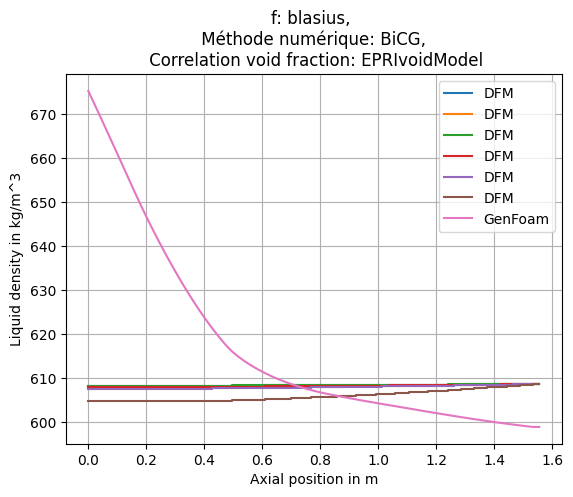

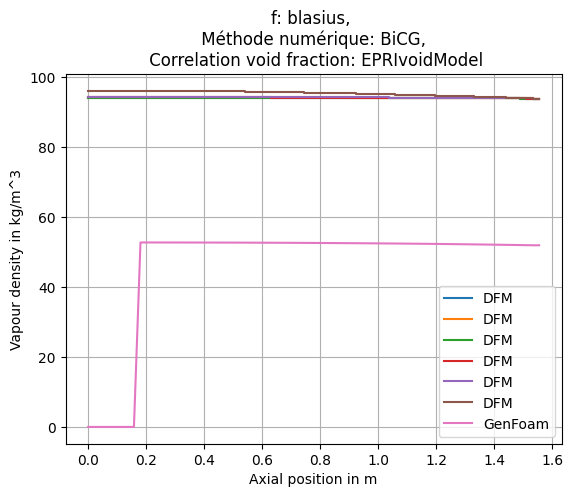

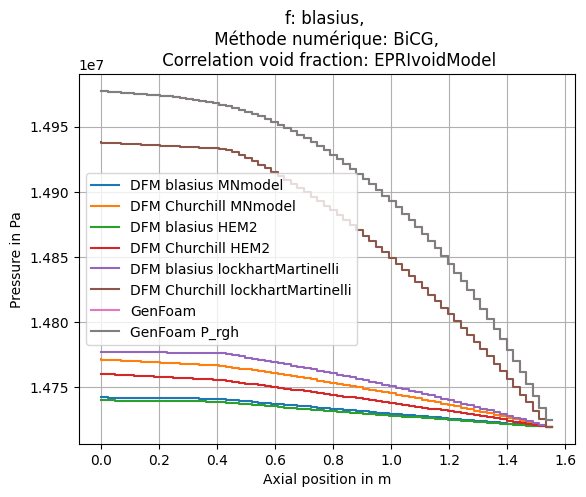

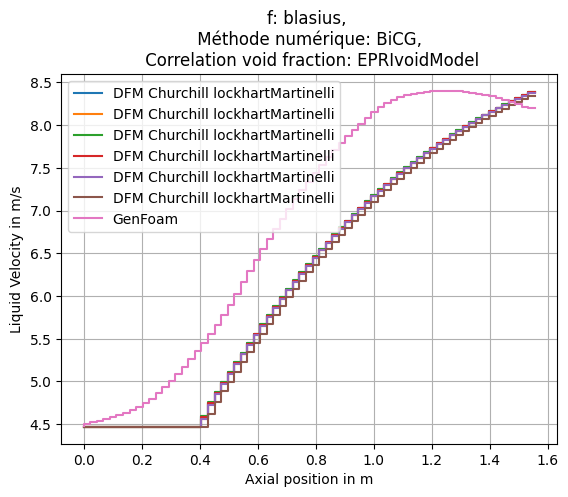

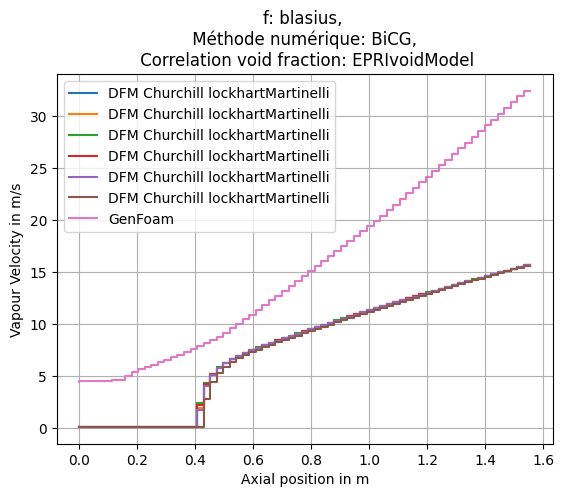

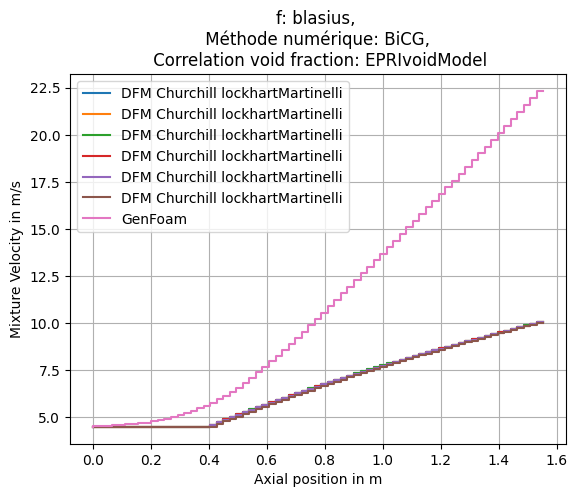

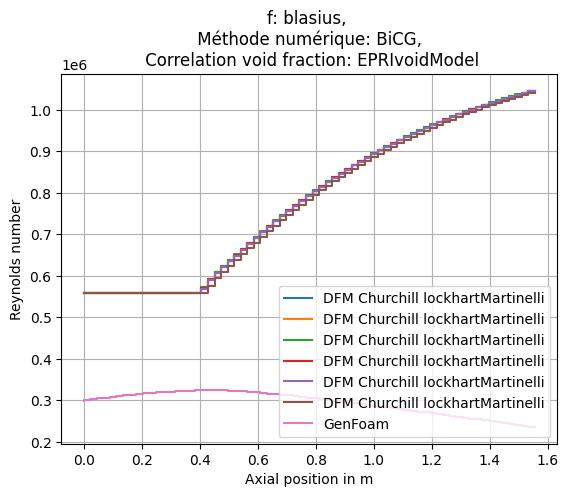

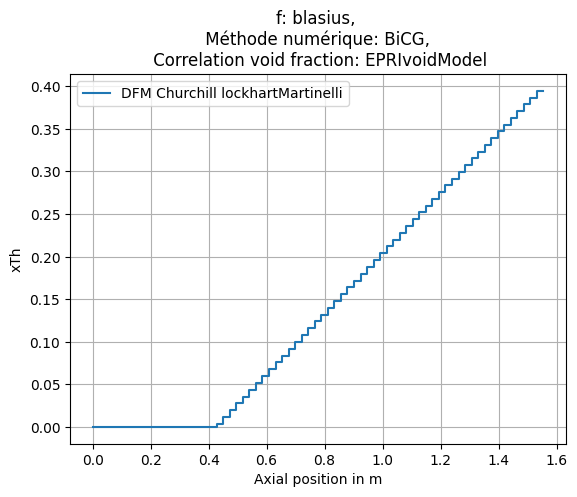

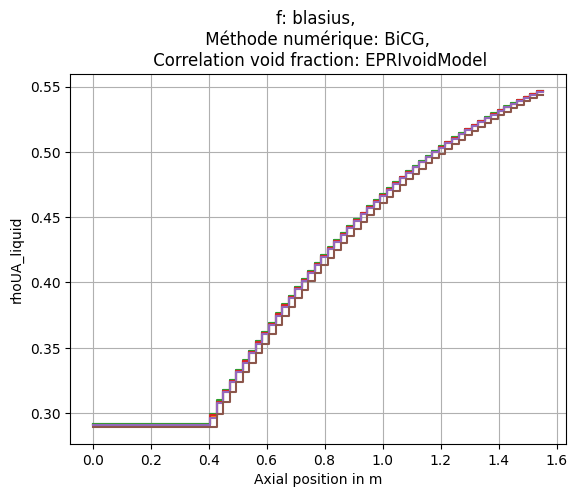

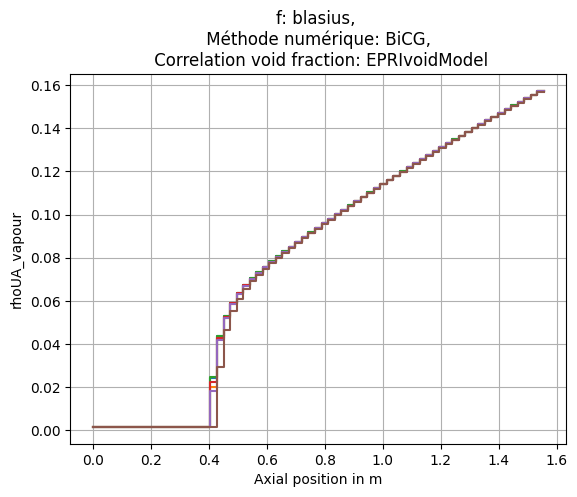

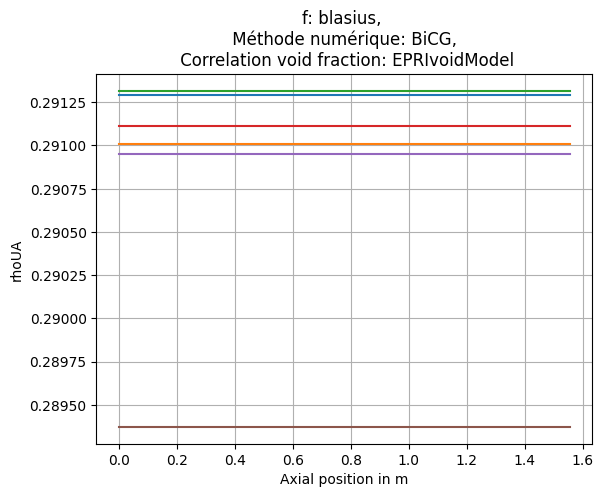

Mean relative error in temperature: 0.18845290280651394, max relative error in temperature 0.4281778455572031 for blasius, MNmodel
Mean relative error in temperature: 0.18462853301044044, max relative error in temperature 0.4507520813812682 for Churchill, MNmodel
Mean relative error in temperature: 0.1888581526484749, max relative error in temperature 0.4262108504549009 for blasius, HEM2
Mean relative error in temperature: 0.18640282846614084, max relative error in temperature 0.4410246718604415 for Churchill, HEM2
Mean relative error in temperature: 0.1833562034285149, max relative error in temperature 0.4592247769843581 for blasius, lockhartMartinelli
Mean relative error in temperature: 0.17015946115652522, max relative error in temperature 0.5113261712442125 for Churchill, lockhartMartinelli
[0.18845290280651394, 0.18462853301044044, 0.1888581526484749, 0.18640282846614084, 0.1833562034285149, 0.17015946115652522]
Reading files in directory: C:\Users\cleme\OneDrive\Documents\Poly\BW

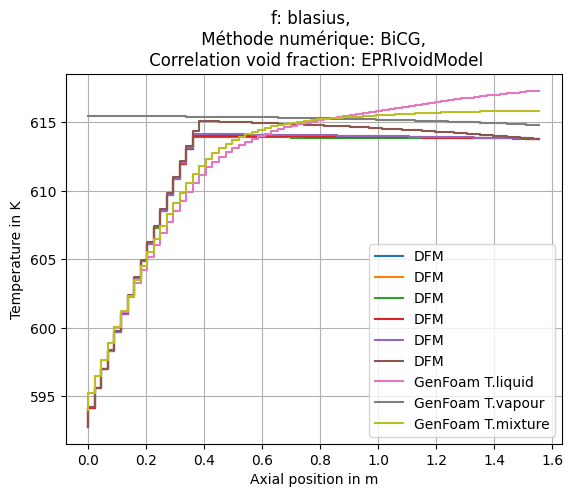

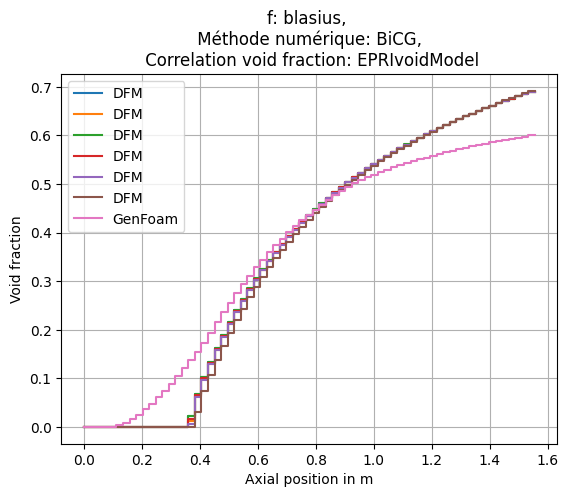

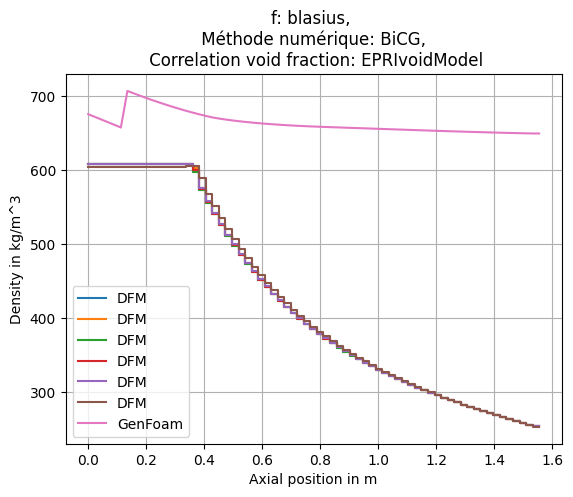

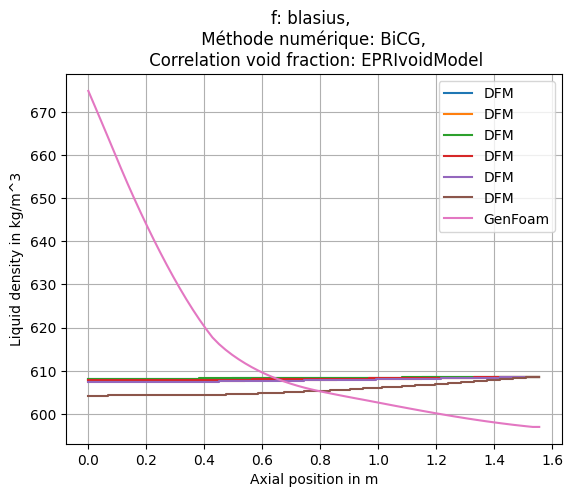

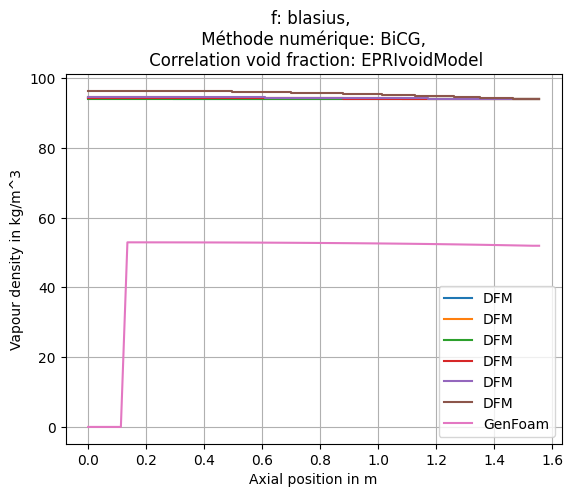

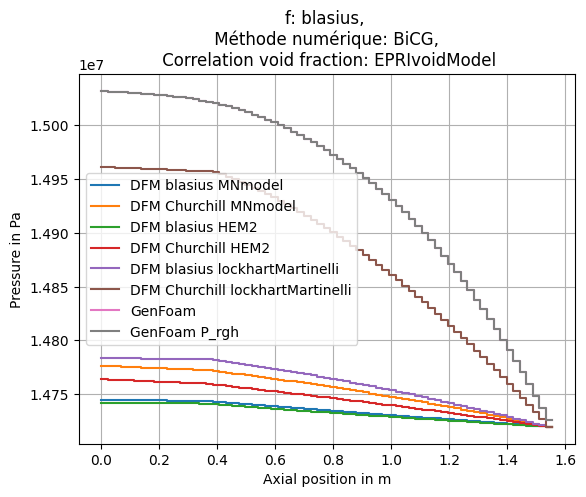

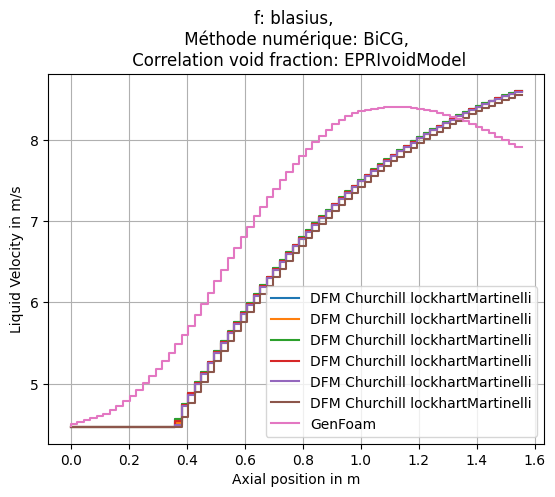

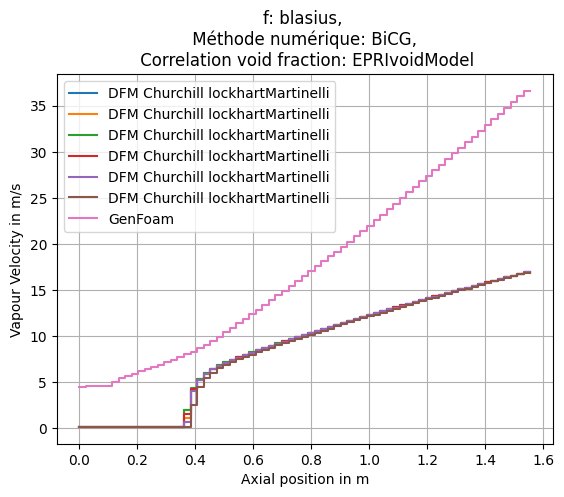

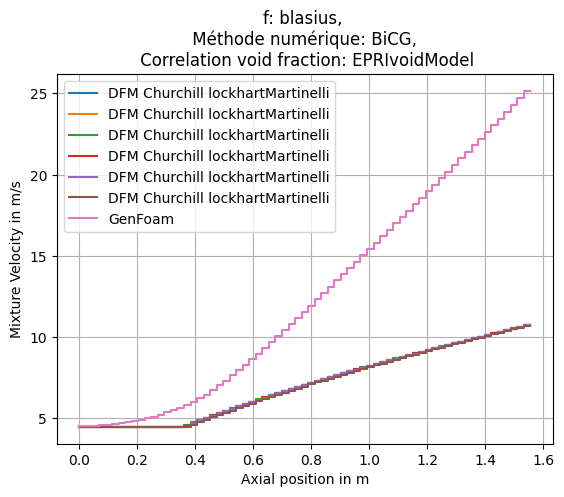

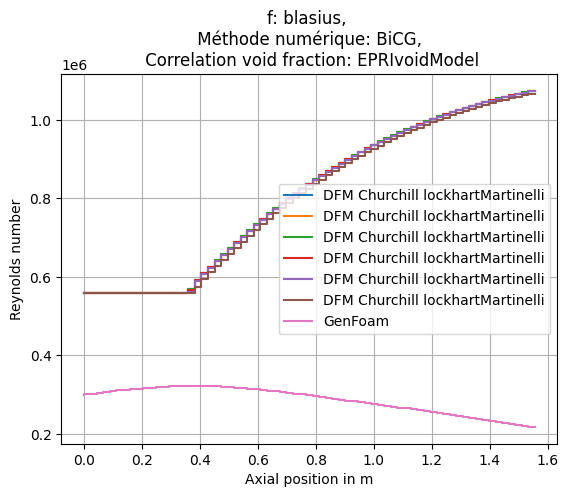

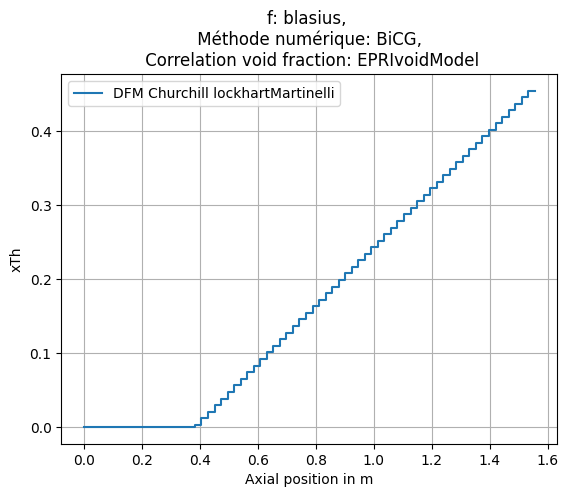

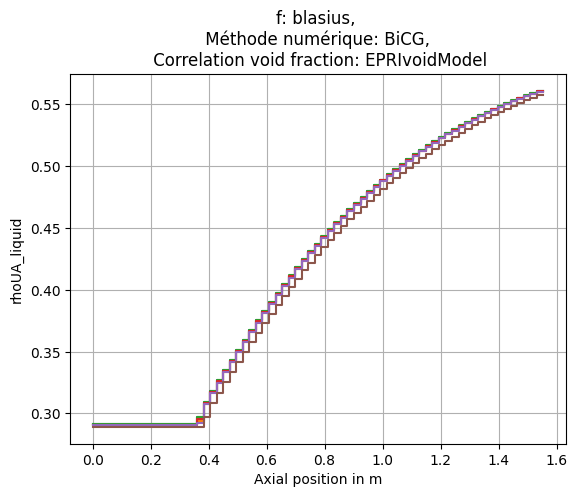

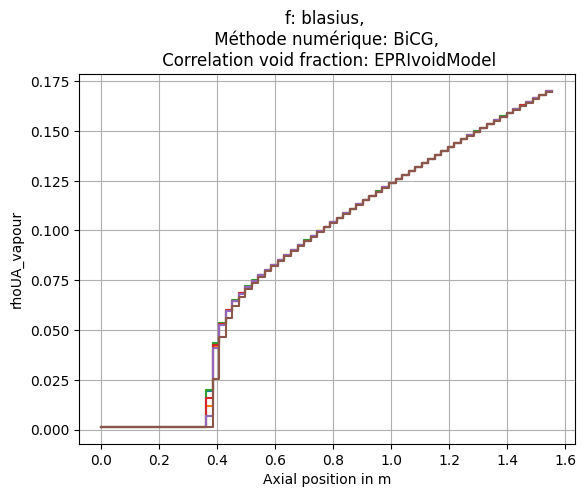

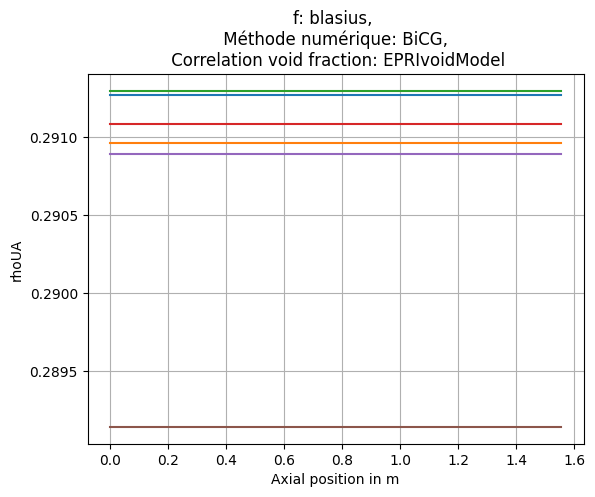

Mean relative error in temperature: 0.21921984381051166, max relative error in temperature 0.4444635812526483 for blasius, MNmodel
Mean relative error in temperature: 0.21392323569543736, max relative error in temperature 0.46966014356512226 for Churchill, MNmodel
Mean relative error in temperature: 0.21973641181641848, max relative error in temperature 0.442242164279026 for blasius, HEM2
Mean relative error in temperature: 0.2164651400142336, max relative error in temperature 0.4586324510927563 for Churchill, HEM2
Mean relative error in temperature: 0.21210169605685866, max relative error in temperature 0.47892237807365795 for blasius, lockhartMartinelli
Mean relative error in temperature: 0.18992831515624967, max relative error in temperature 0.5347749902611465 for Churchill, lockhartMartinelli
[0.21921984381051166, 0.21392323569543736, 0.21973641181641848, 0.2164651400142336, 0.21210169605685866, 0.18992831515624967]
Reading files in directory: C:\Users\cleme\OneDrive\Documents\Poly

" #plotter.plotCase()\nprint(f'Umixture GeN-Foam: {plotter.U_mixture}')\nprint(f'zlist Plotter: {plotter.zList}')\nprint(f'len zListplotter: {len(plotter.zList)}')\nprint(f'zList convection: {case0.convection_sol.z_mesh}')\nprint(f'len z list convection {len(case0.convection_sol.z_mesh)}')\n#print(f'rhoua: {plotter.rhoUA}')  \nprint(f'rhoL GeN-Foam: {case0.convection_sol.rhoL[-1]}')\nprint(f'rhoG GeN-Foam: {case0.convection_sol.rhoG[-1]}')\nprint(f'rho GeN-Foam: {case0.convection_sol.rho[-1]}') "

In [8]:
errors_p=[]
for i in range(len(caseMerge)):
    plotter = GFPlotter(caseMerge[i], rf'C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\Phase_I_Qvariation\{1+i/2}GW', f"Qvariation_{qFiss[i]}GW")
    #plotter.plotComparison()
    plotter.computeErrors()
    errors_p.append(plotter.plotErrorsPressure())

errors_T=[]
for i in range(len(caseMerge)):
    plotter = GFPlotter(caseMerge[i], rf'C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\Phase_I_Qvariation\{1+i/2}GW', f"Qvariation_{qFiss[i]}GW")
    plotter.plotComparison()
    plotter.computeErrors()
    errors_T.append(plotter.plotErrorsTemperature())

errors_eps=[]
for i in range(len(caseMerge)):
    plotter = GFPlotter(caseMerge[i], rf'C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\Phase_I_Qvariation\{1+i/2}GW', f"Qvariation_{qFiss[i]}GW")
    #plotter.plotComparison()
    plotter.computeErrors()
    errors_eps.append(plotter.plotErrorsVoidFraction())


""" #plotter.plotCase()
print(f'Umixture GeN-Foam: {plotter.U_mixture}')
print(f'zlist Plotter: {plotter.zList}')
print(f'len zListplotter: {len(plotter.zList)}')
print(f'zList convection: {case0.convection_sol.z_mesh}')
print(f'len z list convection {len(case0.convection_sol.z_mesh)}')
#print(f'rhoua: {plotter.rhoUA}')  
print(f'rhoL GeN-Foam: {case0.convection_sol.rhoL[-1]}')
print(f'rhoG GeN-Foam: {case0.convection_sol.rhoG[-1]}')
print(f'rho GeN-Foam: {case0.convection_sol.rho[-1]}') """

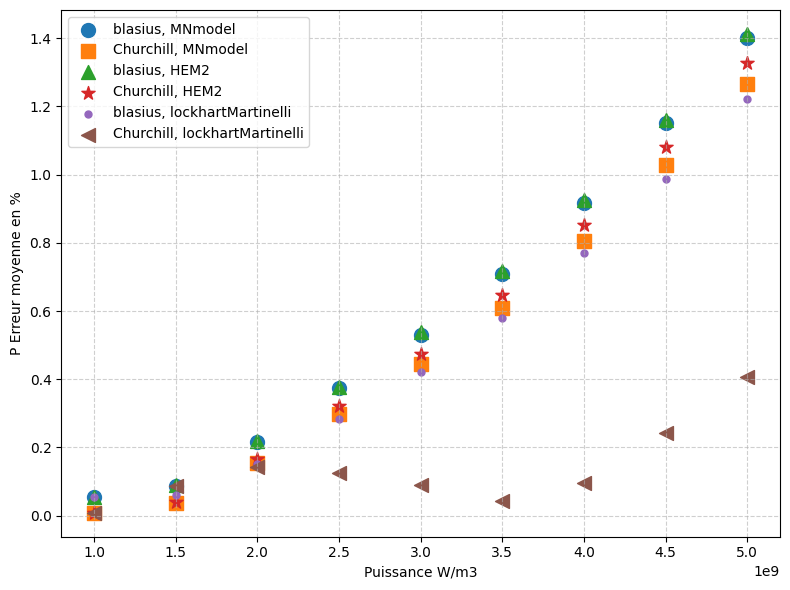

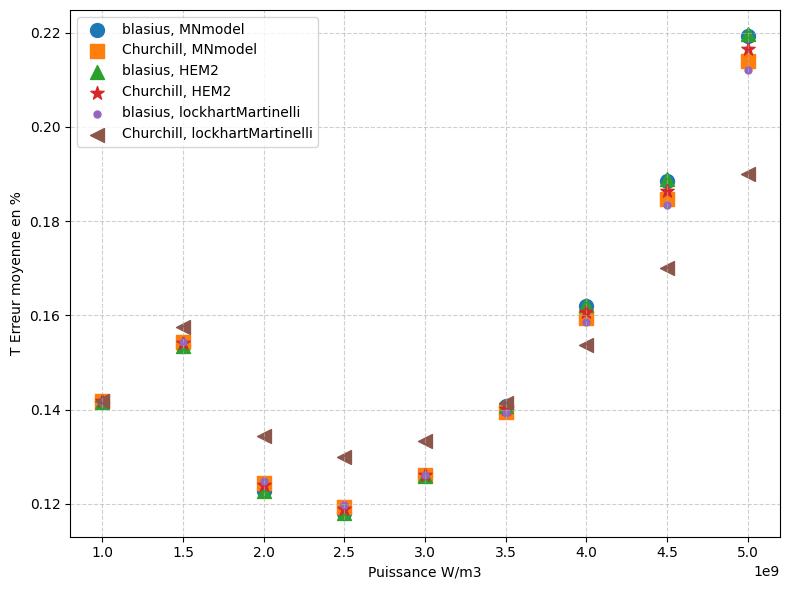

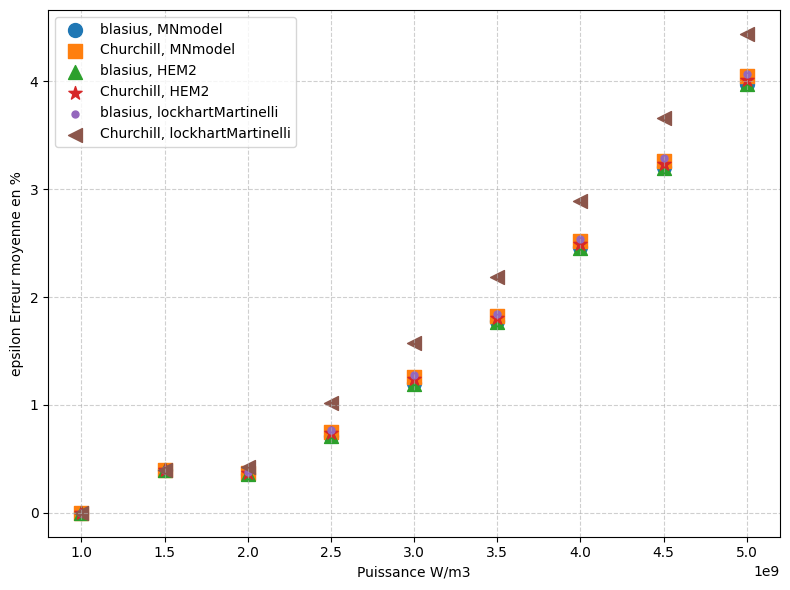

In [6]:
# Symboles pour chaque cas
markers = ['o', 's', '^', '*', '.', '<']  # Cercle, carré, triangle, étoile

cases = {
}

for i in range(len(caseMerge[0])):
    cases[f'{caseMerge[0][i].convection_sol.frfaccorel}, {caseMerge[0][i].convection_sol.P2Pcorel}'] = [errors_p[j][i] for j in range(len(errors_p))]

# Création du graphique
plt.figure(figsize=(8, 6))

for (case_name, errors), marker in zip(cases.items(), markers):
    plt.scatter(qFiss, errors, label=case_name, marker=marker, s=100)

# Ajout des légendes et étiquettes
#plt.title("Erreur moyenne par puissance pour chaque combinaison \n de facteur de friction de multiplicateur biphasique")
plt.xlabel("Puissance W/m3")
plt.ylabel("P Erreur moyenne en %")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()

# Affichage du graphique
plt.show()

cases = {
}

for i in range(len(caseMerge[0])):
    cases[f'{caseMerge[0][i].convection_sol.frfaccorel}, {caseMerge[0][i].convection_sol.P2Pcorel}'] = [errors_T[j][i] for j in range(len(errors_T))]

# Création du graphique
plt.figure(figsize=(8, 6))

for (case_name, errors), marker in zip(cases.items(), markers):
    plt.scatter(qFiss, errors, label=case_name, marker=marker, s=100)

# Ajout des légendes et étiquettes
#plt.title("Erreur moyenne sur la temparature par puissance pour chaque combinaison \n de facteur de friction de multiplicateur biphasique")
plt.xlabel("Puissance W/m3")
plt.ylabel("T Erreur moyenne en %")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

cases = {
}

for i in range(len(caseMerge[0])):
    cases[f'{caseMerge[0][i].convection_sol.frfaccorel}, {caseMerge[0][i].convection_sol.P2Pcorel}'] = [errors_eps[j][i] for j in range(len(errors_eps))]

# Création du graphique
plt.figure(figsize=(8, 6))

for (case_name, errors), marker in zip(cases.items(), markers):
    plt.scatter(qFiss, errors, label=case_name, marker=marker, s=100)

# Ajout des légendes et étiquettes
#plt.title("Erreur moyenne sur la fraction de vide par puissance pour chaque combinaison \n de facteur de friction de multiplicateur biphasique")
plt.xlabel("Puissance W/m3")
plt.ylabel("epsilon Erreur moyenne en %")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


In [7]:
print(f'volume_fracion_fuel: {(fuelRadius ** 2) / ( cladRadius ** 2)}')
print(f'volume_fracion_clad: {(np.pi *cladRadius ** 2) / waterRadius ** 2}')
q = [flowArea * Qfiss1[i] / (np.pi * fuelRadius ** 2) for i in range(len(Qfiss1))]
print(Qfiss1)
for i in range(len(Qfiss1)):
    print(q[i])

volume_fracion_fuel: 0.32590017062773124
volume_fracion_clad: 0.3982265958849156
[5000000000, 5000000000, 5000000000, 5000000000, 5000000000, 5000000000, 5000000000, 5000000000, 5000000000, 5000000000, 5000000000, 5000000000, 5000000000, 5000000000, 5000000000, 5000000000, 5000000000, 5000000000, 5000000000, 5000000000, 5000000000, 5000000000, 5000000000, 5000000000, 5000000000, 5000000000, 5000000000, 5000000000, 5000000000, 5000000000, 5000000000, 5000000000, 5000000000, 5000000000, 5000000000, 5000000000, 5000000000, 5000000000, 5000000000, 5000000000, 5000000000, 5000000000, 5000000000, 5000000000, 5000000000, 5000000000, 5000000000, 5000000000, 5000000000, 5000000000, 5000000000, 5000000000, 5000000000, 5000000000, 5000000000, 5000000000, 5000000000, 5000000000, 5000000000, 5000000000, 5000000000, 5000000000, 5000000000, 5000000000, 5000000000, 5000000000, 5000000000, 5000000000, 5000000000, 5000000000]
23183988085.605114
23183988085.605114
23183988085.605114
23183988085.605114
23